# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of two diffusion-based synthetic data generation models:
1. **TabDDPM** - Conditional Tabular GAN plus
2. **ForestDiffusion** - Forest-based diffusion for tabular data

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


# Generating synthetic data

In [1]:
# Diffusion model dependencies
# TabDDPM: yandex-research/tab-ddpm (_vendor/tab-ddpm)
# ForestDiffusion: pip install ForestDiffusion
# libzero/rtdl pin torch<2; use --no-deps on torch 2.x (TabDDPM still works)
%pip install -q ForestDiffusion xgboost category-encoders imbalanced-learn absl-py tensorboardX icecream dython optuna skorch pyarrow tomli tomli-w
%pip install -q "pynvml>=11,<12"
%pip install -q "libzero==0.0.8" "rtdl==0.0.13" --no-deps

import sys
from pathlib import Path

NOTEBOOK_DIR = Path(".").resolve()
REPO_ROOT = next(
    (p for p in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
     if (p / "_vendor" / "tab-ddpm").is_dir()),
    NOTEBOOK_DIR.parents[1],
)
sys.path.insert(0, str(REPO_ROOT / "_vendor" / "tab-ddpm"))
sys.path.insert(0, str(REPO_ROOT / "_vendor" / "tab-ddpm" / "scripts"))
sys.path.insert(0, str(NOTEBOOK_DIR))

# Verify vendored TabDDPM checkouts (see README Setup)
_vendor_missing = [
    p.name for p in [
        REPO_ROOT / "_vendor" / "tab-ddpm",
    ]
    if not p.exists()
]
if _vendor_missing:
    raise FileNotFoundError(
        "Missing _vendor checkouts: "
        + ", ".join(_vendor_missing)
        + ". Clone per README: git clone https://github.com/yandex-research/tab-ddpm _vendor/tab-ddpm"
    )

from diffusion_generators import (
    MODEL_ORDER,
    train_tabddpm,
    train_forestdiffusion,
)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# -----------------------------
# Load CDC Diabetes Health Indicators dataset
# -----------------------------
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# Data (as one DataFrame)
data = pd.concat([X, y], axis=1)

# Target column is "Diabetes_binary"
target_col = "Diabetes_binary"

# Diabetes_binary is a binary classification target (0/1)
data[target_col] = pd.to_numeric(data[target_col], errors="coerce")
data = data.dropna(subset=[target_col])
data[target_col] = data[target_col].round().astype(int)

# Take only 1000 real samples (dataset is huge, no missing values)
n_samples = 1000
data = data.sample(n=n_samples, random_state=42).reset_index(drop=True)
X = data.drop(columns=[target_col])

from sklearn.preprocessing import StandardScaler, LabelEncoder


# -----------------------------
# Benchmark subsample + leak-safe split (generators fit train only)
# -----------------------------
from sklearn.model_selection import train_test_split

_bench_n = min(1000, len(data))
data = data.sample(n=_bench_n, random_state=42).reset_index(drop=True)

_strat = data[target_col] if data[target_col].nunique() <= 30 else None
train_real, test_real = train_test_split(
    data, test_size=0.2, random_state=42, stratify=_strat,
)
# -----------------------------
# Diffusion models (TabDDPM, ForestDiffusion)
# -----------------------------
SYNTHETIC_N = 1000
DIFFUSION_SEED = 42
_categorical_columns = [target_col]
print("Training TabDDPM...")
synthetic_tabddpm = train_tabddpm(
    train_real,
    target_col='Diabetes_binary',
    categorical_columns=_categorical_columns,
    n_samples=SYNTHETIC_N,
    seed=DIFFUSION_SEED,
)
print("Training ForestDiffusion...")
synthetic_forestdiffusion = train_forestdiffusion(
    train_real,
    target_col='Diabetes_binary',
    categorical_columns=_categorical_columns,
    n_samples=SYNTHETIC_N,
    seed=DIFFUSION_SEED,
)

synthetic_outputs = {
    "TabDDPM": synthetic_tabddpm,
    "ForestDiffusion": synthetic_forestdiffusion,
}
model_order = ["TabDDPM", "ForestDiffusion"]


Training TabDDPM...
[0]
23
{'num_classes': 2, 'is_y_cond': False, 'rtdl_params': {'d_layers': [256, 256, 256], 'dropout': 0.0}, 'd_in': np.int64(23)}
mlp
Step 500/1000 MLoss: 0.0 GLoss: 0.4861 Sum: 0.4861
Step 1000/1000 MLoss: 0.0 GLoss: 0.3626 Sum: 0.3626
mlp
Sample timestep    0
Discrete cols: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Num shape:  (1000, 21)
Training ForestDiffusion...
ForestDiffusion fast_mode: n_t=8, duplicate_K=10, n_estimators=30, max_depth=5, n_jobs=4, gpu_hist=True


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 1782.95it/s]|
Column Shapes Score: 71.24%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 413.10it/s]|
Column Pair Trends Score: 34.2%

Overall Score (Average): 52.72%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 427.79it/s]|
Column Shapes Score: 75.56%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 354.72it/s]|
Column Pair Trends Score: 40.23%

Overall Score (Average): 57.89%



/tmp/ipykernel_2431845/1043430486.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2431845/1043430486.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


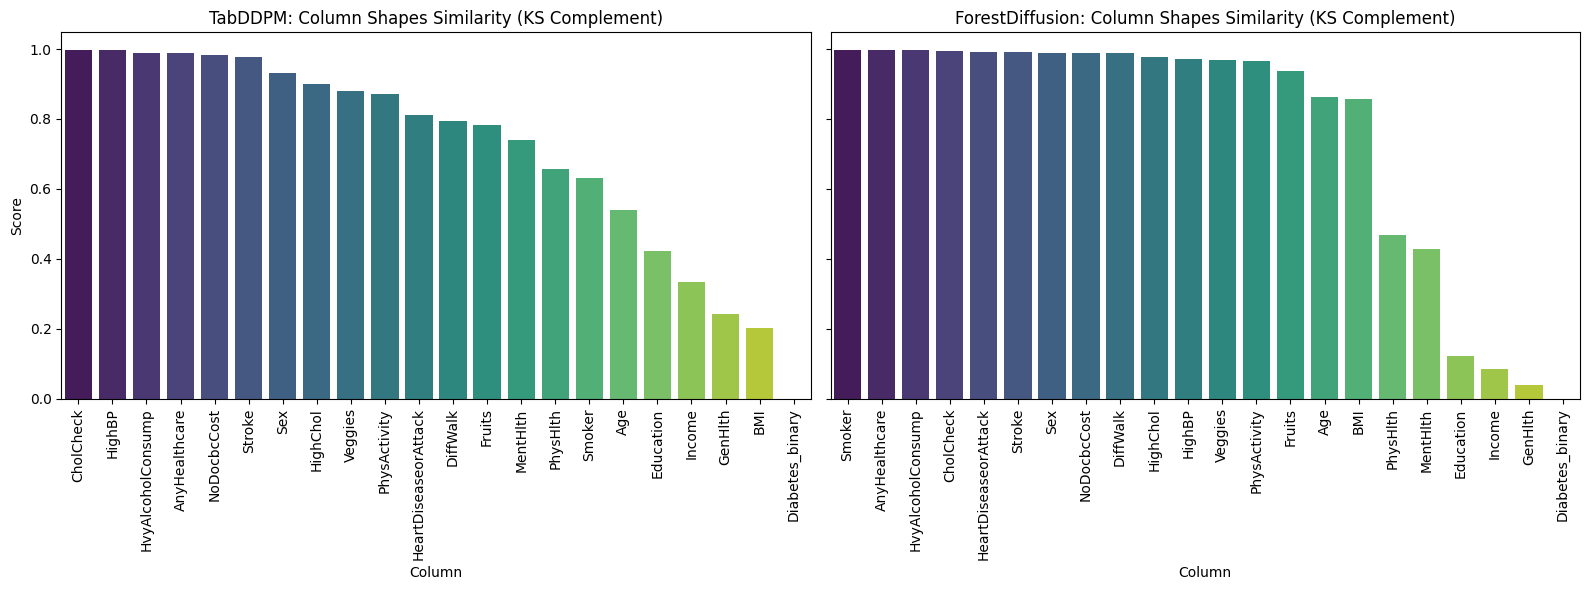

,Model,Average_Column_Shapes_Score
1,ForestDiffusion,0.755591
0,TabDDPM,0.712364


,Column,Metric,Score,Model
0,CholCheck,TVComplement,0.998,TabDDPM
1,HighBP,TVComplement,0.996,TabDDPM
2,HvyAlcoholConsump,TVComplement,0.990,TabDDPM
3,AnyHealthcare,TVComplement,0.990,TabDDPM
4,NoDocbcCost,TVComplement,0.982,TabDDPM
5,Stroke,TVComplement,0.977,TabDDPM
6,Sex,TVComplement,0.931,TabDDPM
7,HighChol,TVComplement,0.899,TabDDPM
8,Veggies,TVComplement,0.880,TabDDPM
9,PhysActivity,TVComplement,0.871,TabDDPM


In [3]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

model_order = ["TabDDPM", "ForestDiffusion"]
column_shape_details = {}
summary_rows = []

for model_name in model_order:
    qr = QualityReport()
    qr.generate(
        real_data=data,
        synthetic_data=synthetic_outputs[model_name],
        metadata=metadata.to_dict()
    )

    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

    summary_rows.append({
        "Model": model_name,
        "Average_Column_Shapes_Score": float(details["Score"].mean())
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Average_Column_Shapes_Score", ascending=False)

fig, axes = plt.subplots(1, len(model_order), figsize=(16, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column",
        y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

display(summary_df)

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))


### 1.2. Jensen–Shannon divergence

In [4]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")


/tmp/ipykernel_2431845/3120368892.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_2431845/3120368892.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


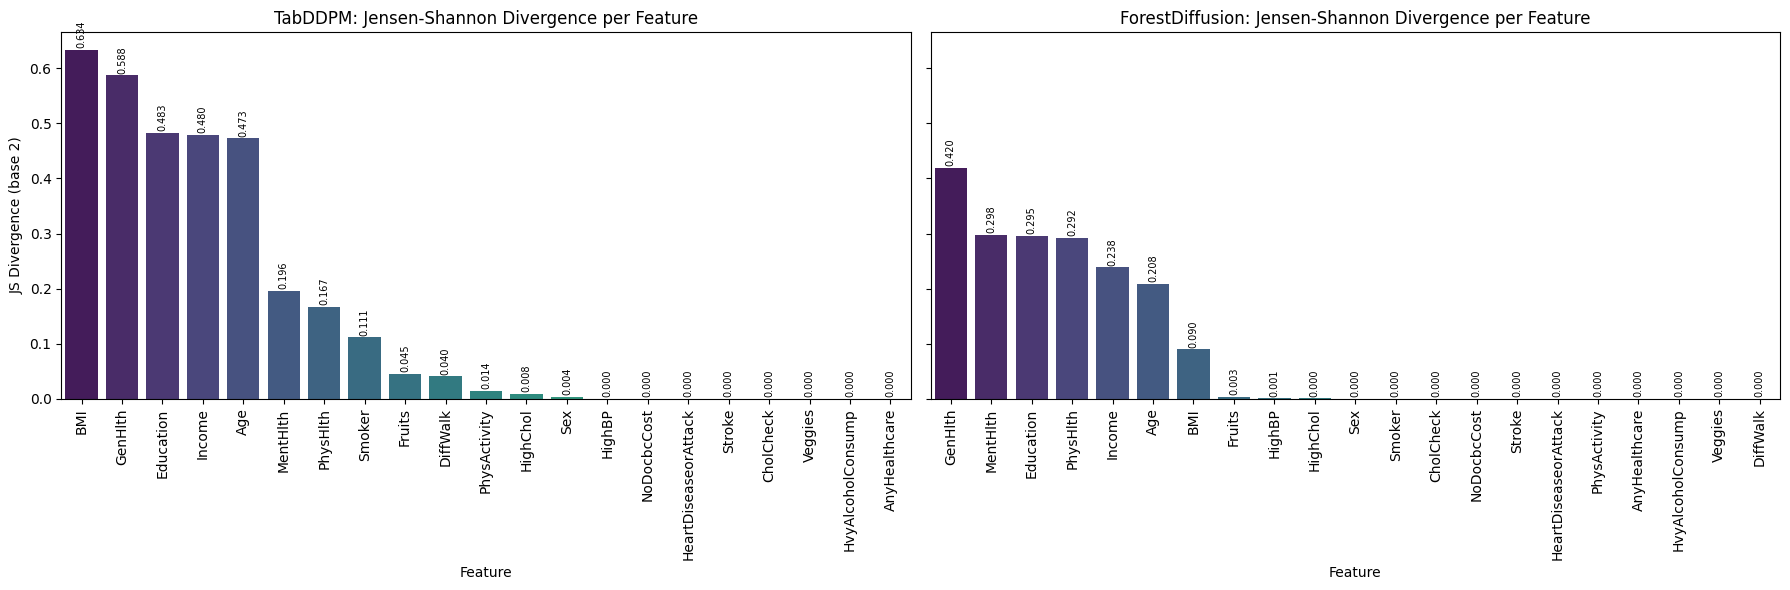

,Feature,JS_Divergence,Model
0,BMI,0.633867,TabDDPM
1,GenHlth,0.587574,TabDDPM
2,Education,0.483211,TabDDPM
3,Income,0.479512,TabDDPM
4,Age,0.472643,TabDDPM
5,MentHlth,0.196300,TabDDPM
6,PhysHlth,0.166686,TabDDPM
7,Smoker,0.111158,TabDDPM
8,Fruits,0.044652,TabDDPM
9,DiffWalk,0.040392,TabDDPM


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# remove target column from the comparison
real_df = data.drop(columns=[target_col], axis = 1)

model_order = ["TabDDPM", "ForestDiffusion"]
js_results_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col])
    js_df = compute_js_divergence(
        real_df,
        synth_df,
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

fig, axes = plt.subplots(1, len(model_order), figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))


### 1.3 Wasserstein Distance



TabDDPM - Wasserstein Distance:
HighBP: 0.0040
HighChol: 0.1010
CholCheck: 0.0020
BMI: 0.6308
Smoker: 0.3680
Stroke: 0.0230
HeartDiseaseorAttack: 0.1890
PhysActivity: 0.1290
Fruits: 0.2160
Veggies: 0.1200
HvyAlcoholConsump: 0.0100
AnyHealthcare: 0.0100
NoDocbcCost: 0.0180
GenHlth: 0.4515
MentHlth: 0.2039
PhysHlth: 0.2820
DiffWalk: 0.2050
Sex: 0.0690
Age: 0.2645
Education: 0.2946
Income: 0.4331

ForestDiffusion - Wasserstein Distance:
HighBP: 0.0270
HighChol: 0.0240
CholCheck: 0.0050
BMI: 0.0235
Smoker: 0.0030
Stroke: 0.0090
HeartDiseaseorAttack: 0.0070
PhysActivity: 0.0330
Fruits: 0.0630
Veggies: 0.0320
HvyAlcoholConsump: 0.0040
AnyHealthcare: 0.0030
NoDocbcCost: 0.0100
GenHlth: 0.0522
MentHlth: 0.0320
PhysHlth: 0.0305
DiffWalk: 0.0110
Sex: 0.0100
Age: 0.0393
Education: 0.0387
Income: 0.0480

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,ForestDiffusion,0.024058,0.024,0.063000
1,TabDDPM,0.191641,0.189,0.630757


/tmp/ipykernel_2431845/1288214965.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2431845/1288214965.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


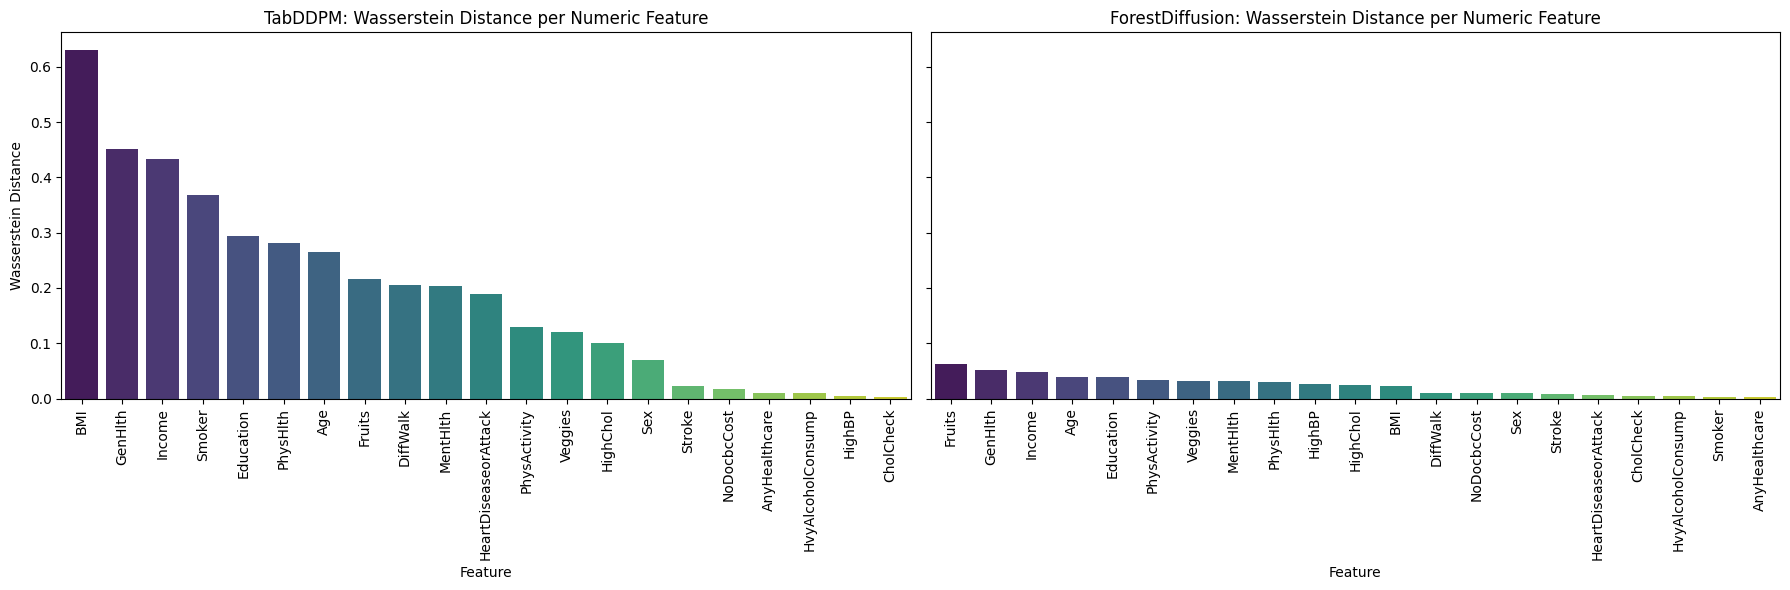

In [6]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for np.number

model_order = ["TabDDPM", "ForestDiffusion"]

# Get the target column name (it's 'y' as per the kernel state)
# Assuming 'target_col' is available from previous cells.
# If not, it would need to be defined here. For this context, it is 'y'.
target_col = "Diabetes_binary"

# Remove target variable from real data
real_df_for_metrics = data.drop(columns=[target_col])

# Identify numeric columns for scaling and Wasserstein distance calculation
numeric_cols = real_df_for_metrics.select_dtypes(include=np.number).columns.tolist()

# Create a DataFrame containing only numeric columns from the real data
real_numeric_df = real_df_for_metrics[numeric_cols]

scaler = MinMaxScaler()
# Fit and transform only the numeric columns of the real data
real_scaled_numeric = pd.DataFrame(
    scaler.fit_transform(real_numeric_df),
    columns=numeric_cols,
    index=real_numeric_df.index
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    # Drop the target column from synthetic data
    synth_df_for_metrics = synthetic_outputs[model_name].drop(columns=[target_col])

    # Ensure synthetic data has the same numeric columns as real data
    # and in the same order before scaling
    synth_numeric_df = synth_df_for_metrics[numeric_cols]

    # Transform synthetic numeric columns using the *same scaler* fitted on real data
    synthetic_scaled_numeric = pd.DataFrame(
        scaler.transform(synth_numeric_df),
        columns=numeric_cols,
        index=synth_numeric_df.index
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    # Calculate Wasserstein distance only for numeric columns
    for col in numeric_cols:
        dist = wasserstein_distance(real_scaled_numeric[col], synthetic_scaled_numeric[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(
        dists,
        columns=["Feature", "Wasserstein_Distance"]
    ).sort_values("Wasserstein_Distance", ascending=False)

    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(1, len(model_order), figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Numeric Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()


### 1.4 Gower Distance

In [7]:
pip install gower

Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import pandas as pd
import gower

model_order = ["TabDDPM", "ForestDiffusion"]
# FIX: Correct target_col to "Diabetes_binary" based on context and kernel state
target_col = "Diabetes_binary"

X_real = data.drop(columns=[target_col], errors="ignore")

gower_results = []

for model_name in model_order:
    X_synth = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True)
    Xs = X_synth[common_cols].reset_index(drop=True)

    # FIX: Convert all numeric columns to float to avoid UFuncTypeError in gower.gower_matrix
    # Identify numeric columns
    numeric_cols_Xr = Xr.select_dtypes(include=np.number).columns
    numeric_cols_Xs = Xs.select_dtypes(include=np.number).columns

    # Convert them to float
    Xr[numeric_cols_Xr] = Xr[numeric_cols_Xr].astype(float)
    Xs[numeric_cols_Xs] = Xs[numeric_cols_Xs].astype(float)

    gower_real = 1 - gower.gower_matrix(Xr)
    gower_synth = 1 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = np.max(real_upper)
    avg_intra_real = np.mean(real_upper)
    max_intra_synth = np.max(synth_upper)
    avg_intra_synth = np.mean(synth_upper)

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    # FIX: Convert all numeric columns in combined to float
    numeric_cols_combined = combined.select_dtypes(include=np.number).columns
    combined[numeric_cols_combined] = combined[numeric_cols_combined].astype(float)

    gower_combined = 1 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = np.max(cross_block)
    avg_cross = np.mean(cross_block)

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)



TabDDPM - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7315

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.6613

Cross-set Similarity (Real vs Synthetic):
Max = 0.9997, Avg = 0.6208

ForestDiffusion - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7315

Intra-set Similarity (Synthetic):
Max = 0.9993, Avg = 0.7525

Cross-set Similarity (Real vs Synthetic):
Max = 0.9991, Avg = 0.7419


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,TabDDPM,1.0,0.731482,1.000000,0.661279,0.999694,0.620838
1,ForestDiffusion,1.0,0.731482,0.999287,0.752504,0.999100,0.741913


### 1.5 t-SNE Visualization


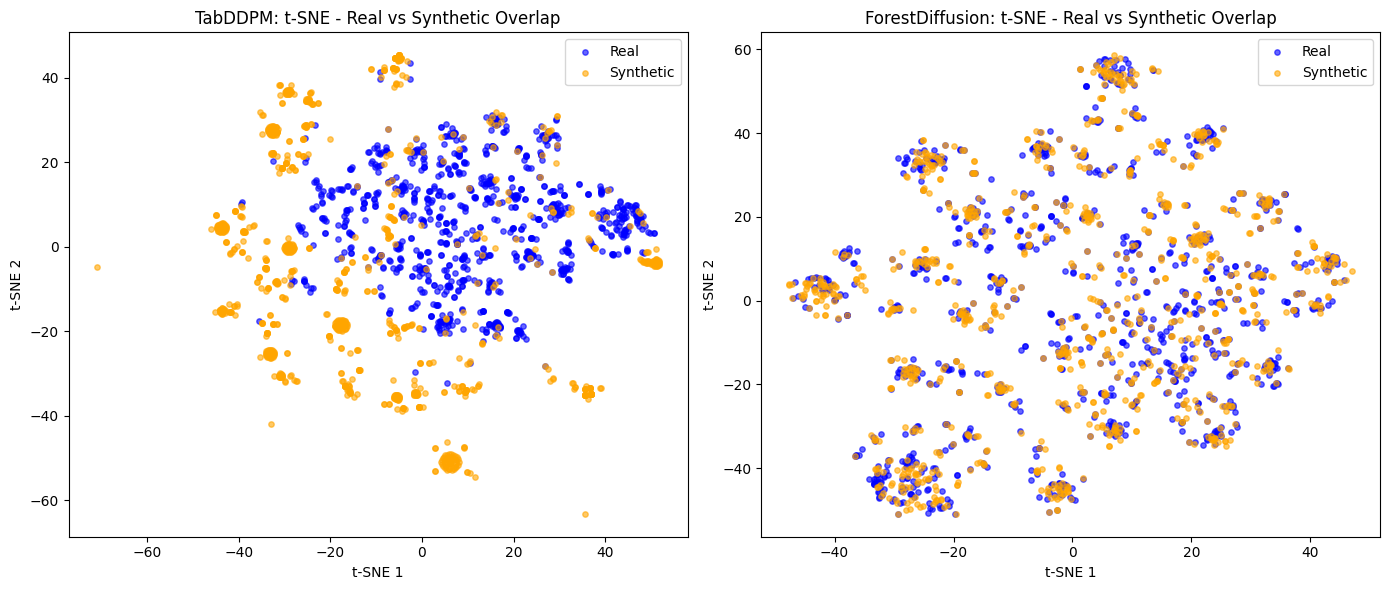

In [9]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "Diabetes_binary"

# remove target from real data
X_real = data.drop(columns=[target_col], errors="ignore")

# Select only numeric columns for scaling
numeric_cols = X_real.select_dtypes(include=np.number).columns
X_real_numeric = X_real[numeric_cols]

# scale real data once
scaler = MinMaxScaler()
real_scaled_numeric = pd.DataFrame(
    scaler.fit_transform(X_real_numeric),
    columns=numeric_cols
)

# create 1x2 t-SNE plots
fig, axes = plt.subplots(1, len(model_order), figsize=(14, 6))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # keep same numeric columns/order for synthetic data
    synth_numeric = synth_df[numeric_cols]

    synthetic_scaled_numeric = pd.DataFrame(
        scaler.transform(synth_numeric),
        columns=numeric_cols
    )

    combined = np.vstack([real_scaled_numeric.values, synthetic_scaled_numeric.values])
    labels = np.array(["Real"] * len(real_scaled_numeric) + ["Synthetic"] * len(synthetic_scaled_numeric))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()


### 1.6 MMD (Maximum Mean Discrepancy)


In [10]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile) ** 2, axis=1) / (2 * dim * sigma ** 2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "Diabetes_binary"

# Real features (exclude target)
real_features = data.drop(columns=[target_col], errors="ignore")

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # Align columns/order and select only numeric features
    common_numeric_cols = real_features.select_dtypes(include=np.number).columns.intersection(
        synth_df.select_dtypes(include=np.number).columns
    )
    X_real = real_features[common_numeric_cols]
    X_synth = synth_df[common_numeric_cols]

    # Standardize using real-data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_score = compute_mmd(X_real_scaled, X_synth_scaled, sigma=1.0)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.4f}")

# Lower MMD is better
mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)


TabDDPM - MMD score: 0.3658
ForestDiffusion - MMD score: 0.0033

MMD comparison (lower is better):


,Model,MMD_Score
0,ForestDiffusion,0.003334
1,TabDDPM,0.365759


### 1.7 Cosine Similarity


In [11]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "Diabetes_binary"

real_features = data.drop(columns=[target_col], errors="ignore")
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # Align columns/order and select only numeric features
    common_numeric_cols = real_features.select_dtypes(include=np.number).columns.intersection(
        synth_df.select_dtypes(include=np.number).columns
    )
    X_real = real_features[common_numeric_cols]
    X_synth = synth_df[common_numeric_cols]

    # Scale using real data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # Pairwise cross similarity: all real vs all synthetic rows
    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)



TabDDPM - Sample-Level Similarity:
Average cosine similarity: -0.0289
Maximum cosine similarity: 0.9998

ForestDiffusion - Sample-Level Similarity:
Average cosine similarity: 0.0136
Maximum cosine similarity: 0.9997

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,ForestDiffusion,0.013621,0.999669
1,TabDDPM,-0.028947,0.999831


### 1.8 Nearest Neighbours


In [12]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]

real_features = data.drop(columns=[target_col], errors="ignore")
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # Align columns/order
    common_cols = real_features.columns.intersection(synth_df.columns)

    # Select only numeric columns from the common ones
    numeric_common_cols = common_cols.intersection(real_features.select_dtypes(include=np.number).columns)

    X_real_numeric = real_features[numeric_common_cols]
    X_synth_numeric = synth_df[numeric_common_cols]

    # Scale using real data statistics
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real_numeric)
    X_synth_scaled = scaler.transform(X_synth_numeric)

    # Nearest-neighbor privacy check: Synthetic -> Real
    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)



TabDDPM - Privacy Check:
Average NN Distance (Synthetic -> Real): 5.6603
Minimum NN Distance (Synthetic -> Real): 0.0580
5th Percentile NN Distance: 0.9495

ForestDiffusion - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.9947
Minimum NN Distance (Synthetic -> Real): 0.0825
5th Percentile NN Distance: 0.5222

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,TabDDPM,5.660251,0.057986,0.949497
1,ForestDiffusion,1.994686,0.082545,0.522194


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,62.860091,29.042448,42.468087
1,ForestDiffusion,6.246075,4.342105,8.990569


/tmp/ipykernel_2431845/2473399619.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
/tmp/ipykernel_2431845/2473399619.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
/tmp/ipykernel_2431845/2473399619.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")


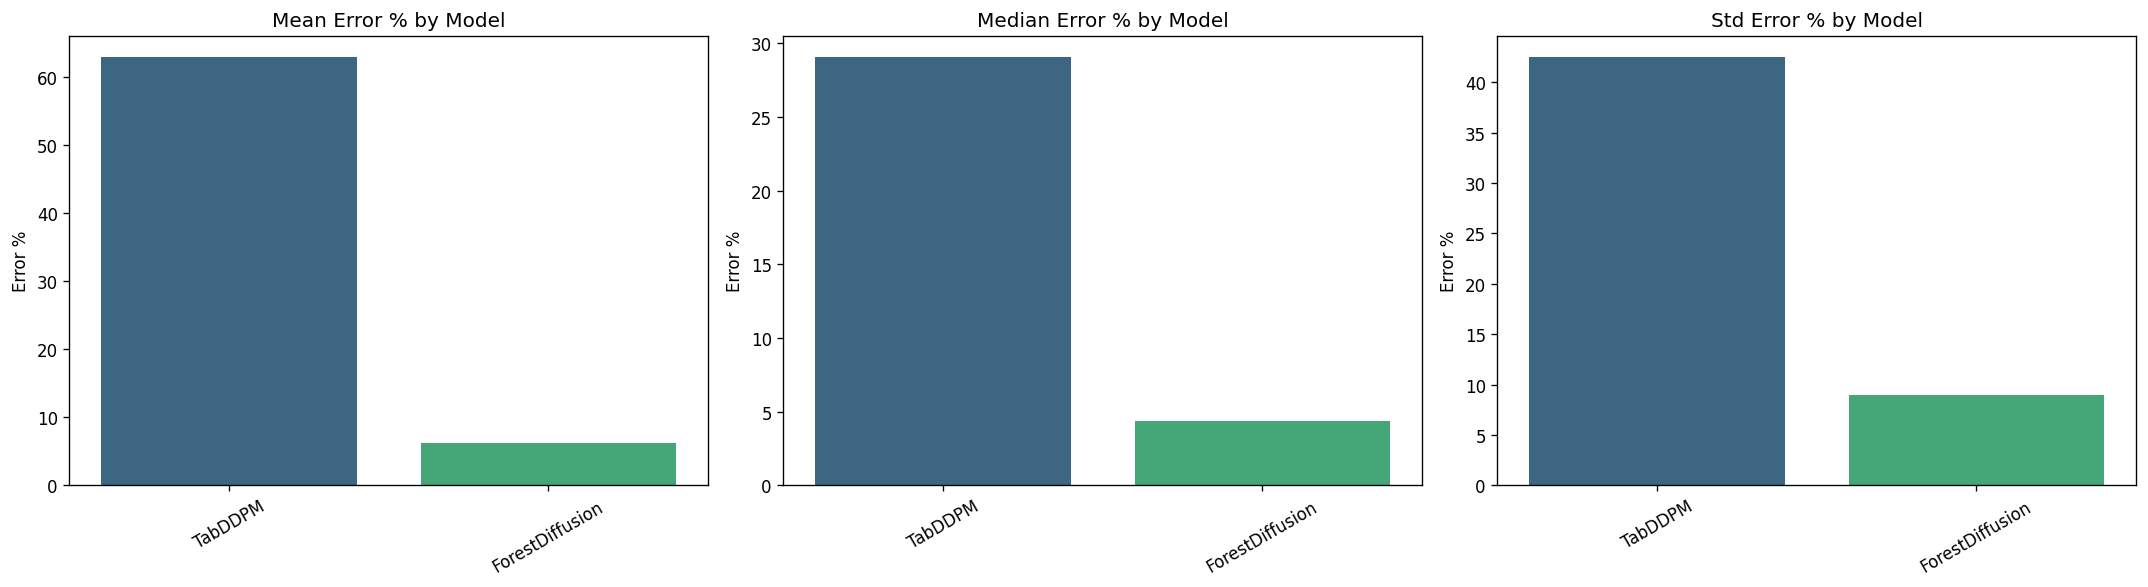

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

def _coerce_numeric_features(df, cols):
    out = df[cols].copy()
    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out

target_col = "Diabetes_binary" # Target column: Diabetes_binary
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_num = _coerce_numeric_features(real_df, num_cols)
    synth_num = _coerce_numeric_features(synth_df, num_cols)
    real_means = real_num.mean()
    synth_means = synth_num.mean()

    real_stds = real_num.std(ddof=1)
    synth_stds = synth_num.std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows).set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2431845/1185619148.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")


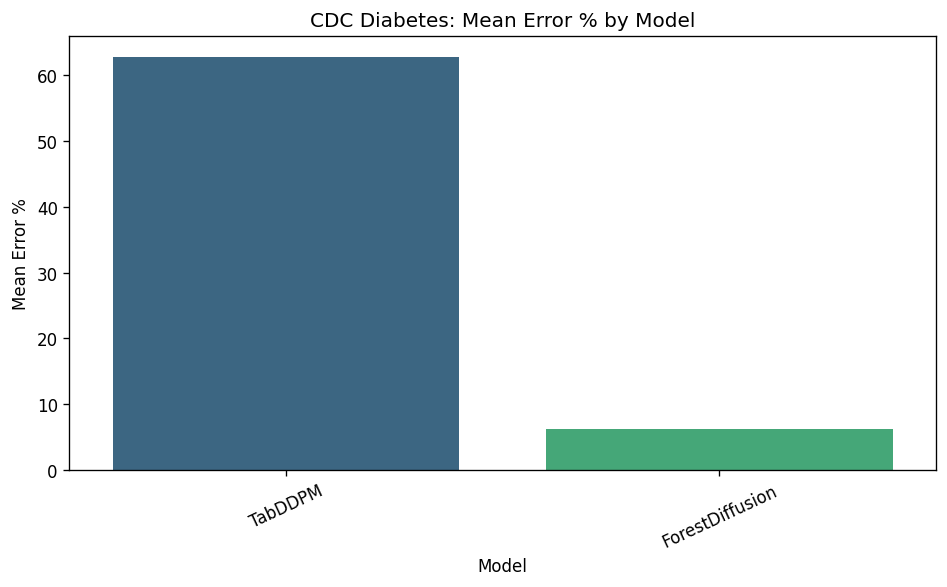

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("CDC Diabetes: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2431845/357289816.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")


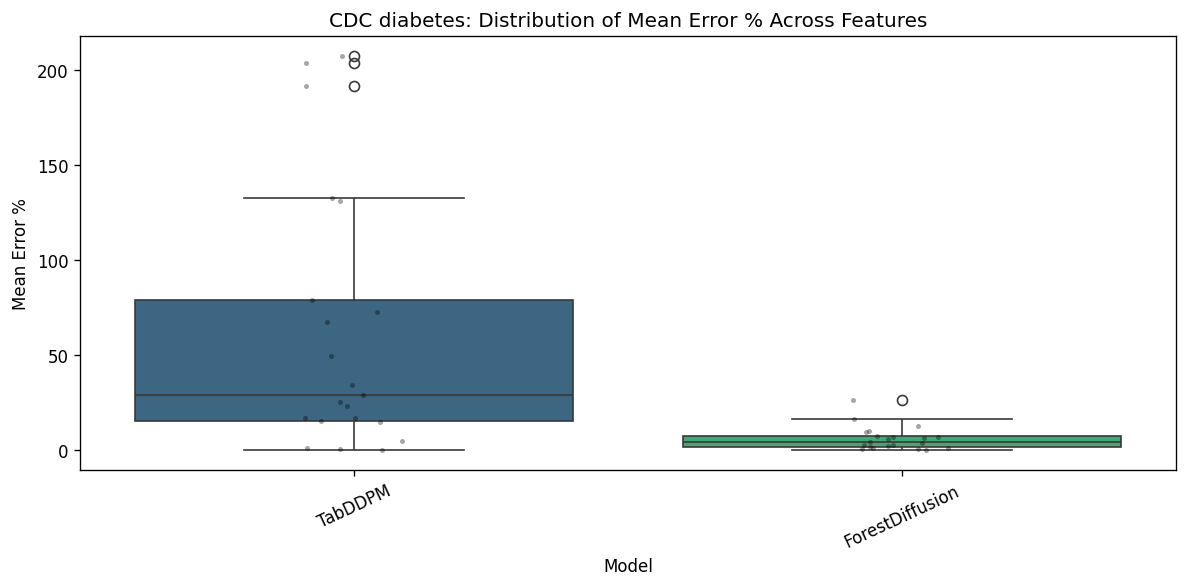

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_list = ["TabDDPM", "ForestDiffusion"]
target_col = "Diabetes_binary"
dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_list
        if m in feature_error_by_model
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("CDC diabetes: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


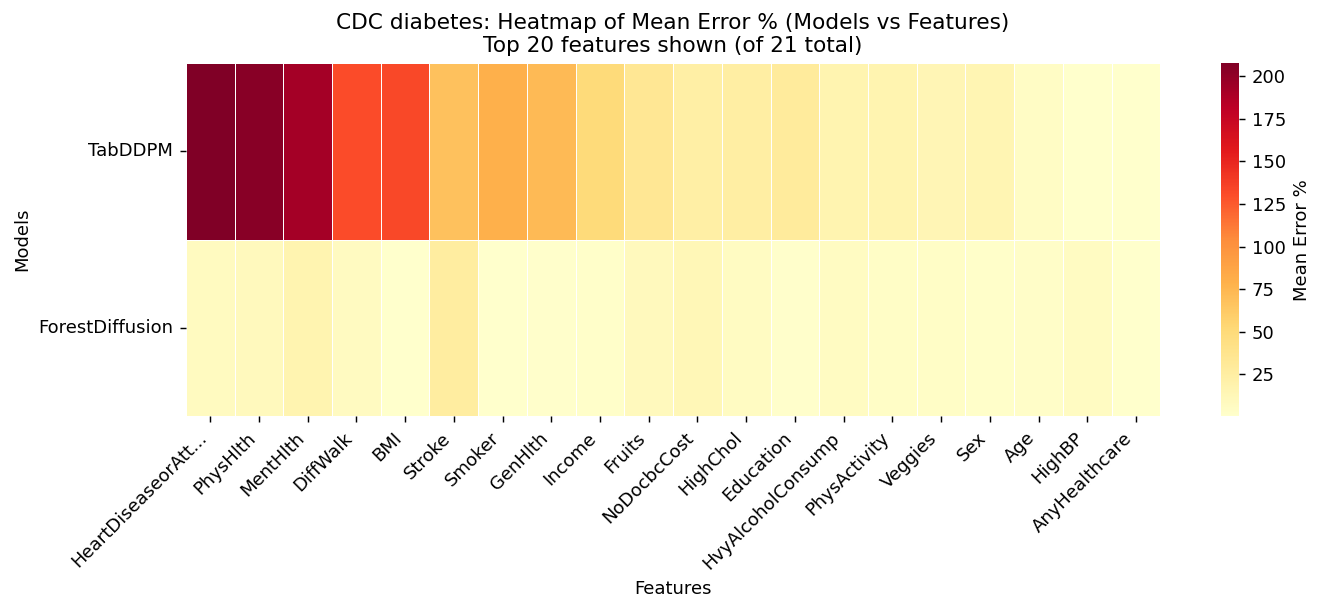

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"CDC diabetes: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 2 Bivariate Analysis


In [17]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

def bivariate_quality(real_df, synth_df, target=None):
    """Compute bivariate quality metrics for cancer data."""

    if target is None:
        for cand in ["Diabetes_binary", "quality", "Class", "class", "target", "Target"]:
            if cand in real_df.columns:
                target = cand
                break

    if target is None or target not in real_df.columns or target not in synth_df.columns:
        # Instead of raising KeyError, return empty DFs if target is not found or not in both
        return pd.DataFrame(columns=["var_a", "var_b", "delta_corr"]), pd.DataFrame(columns=["feature", "delta_median_diff"])

    # Identify numeric columns for correlation analysis, excluding the target column
    num_cols = [
        c for c in real_df.columns
        if c != target and pd.api.types.is_numeric_dtype(real_df[c]) and pd.api.types.is_numeric_dtype(synth_df[c])
    ]

    # Prepare scaled data for correlation (only numeric features)
    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    if num_cols:
        real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
        synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    # For multi-class numeric target, calculate difference in class-wise medians
    results_target = []
    # Get all unique classes (levels) from the real target column
    unique_classes = sorted(real_df[target].unique())

    if len(unique_classes) > 1: # Only proceed if there are multiple classes
        for col in num_cols:
            real_medians = real_df.groupby(target)[col].median().reindex(unique_classes)
            synth_medians = synth_df.groupby(target)[col].median().reindex(unique_classes)

            # Calculate the absolute difference of medians for each class and average them, ignoring NaNs
            diff_medians = np.nanmean(np.abs(real_medians - synth_medians))

            results_target.append({
                "feature": col,
                "delta_median_diff": diff_medians
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_median_diff", ascending=False) if results_target else pd.DataFrame(columns=["feature", "delta_median_diff"])

    return corr_df, target_df


In [18]:
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]

possible_targets = ["Diabetes_binary"]
target_col = next((c for c in possible_targets if c in data.columns), None)

if target_col is None:
    raise KeyError(f"No target column found in data. Available columns: {list(data.columns)}")

real_df = data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # keep target column if it exists, but align numeric features separately inside the function
    if target_col not in synth_df.columns:
        raise KeyError(f"{target_col} not found in synthetic data for {model_name}")

    corr_results, target_results = bivariate_quality(
        real_df=real_df,
        synth_df=synth_df,
        target=target_col
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by diagnosis class:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next((c for c in ["delta_corr", "AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_results.columns), None)
    # Updated to look for 'delta_median_diff' first, then 'delta_wasserstein' for backward compatibility if needed
    target_metric_col = next((c for c in ["delta_median_diff", "delta_wasserstein", "AbsDiff", "abs_diff", "Difference", "diff"] if c in target_results.columns), None)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col and not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col and not corr_results.empty else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col and not target_results.empty and target_metric_col in target_results.columns else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col and not target_results.empty and target_metric_col in target_results.columns else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



TabDDPM - Largest differences in pairwise correlations:


/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))

,var_a,var_b,delta_corr
57,BMI,Smoker,0.484271
74,Smoker,Stroke,0.455893
25,HighChol,PhysActivity,0.406217
37,HighChol,Education,0.405915
24,HighChol,HeartDiseaseorAttack,0.385168
207,Age,Education,0.368918
148,Veggies,MentHlth,0.347026
143,Fruits,Income,0.343061
125,PhysActivity,MentHlth,0.329791
11,HighBP,NoDocbcCost,0.319775


TabDDPM - Features that differ most by diagnosis class:


,feature,delta_median_diff
0,HighBP,NaN
1,HighChol,NaN
2,CholCheck,NaN
3,BMI,NaN
4,Smoker,NaN
5,Stroke,NaN
6,HeartDiseaseorAttack,NaN
7,PhysActivity,NaN
8,Fruits,NaN
9,Veggies,NaN


...

/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))
/tmp/ipykernel_2431845/3165926046.py:56: RuntimeWarning: Mean of empty slice
  diff_medians = np.nanmean(np.abs(real_medians - synth_medians))

,var_a,var_b,delta_corr
90,Stroke,HeartDiseaseorAttack,0.230730
24,HighChol,HeartDiseaseorAttack,0.163796
103,Stroke,Education,0.123688
165,AnyHealthcare,NoDocbcCost,0.118519
20,HighChol,CholCheck,0.118274
114,HeartDiseaseorAttack,DiffWalk,0.115998
195,PhysHlth,DiffWalk,0.114087
30,HighChol,NoDocbcCost,0.112733
99,Stroke,PhysHlth,0.110688
48,CholCheck,NoDocbcCost,0.109439


ForestDiffusion - Features that differ most by diagnosis class:


,feature,delta_median_diff
0,HighBP,NaN
1,HighChol,NaN
2,CholCheck,NaN
3,BMI,NaN
4,Smoker,NaN
5,Stroke,NaN
6,HeartDiseaseorAttack,NaN
7,PhysActivity,NaN
8,Fruits,NaN
9,Veggies,NaN


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,TabDDPM,0.484271,0.384604,NaN,NaN
1,ForestDiffusion,0.230730,0.131795,NaN,NaN


### 3 Multivariate Analysis


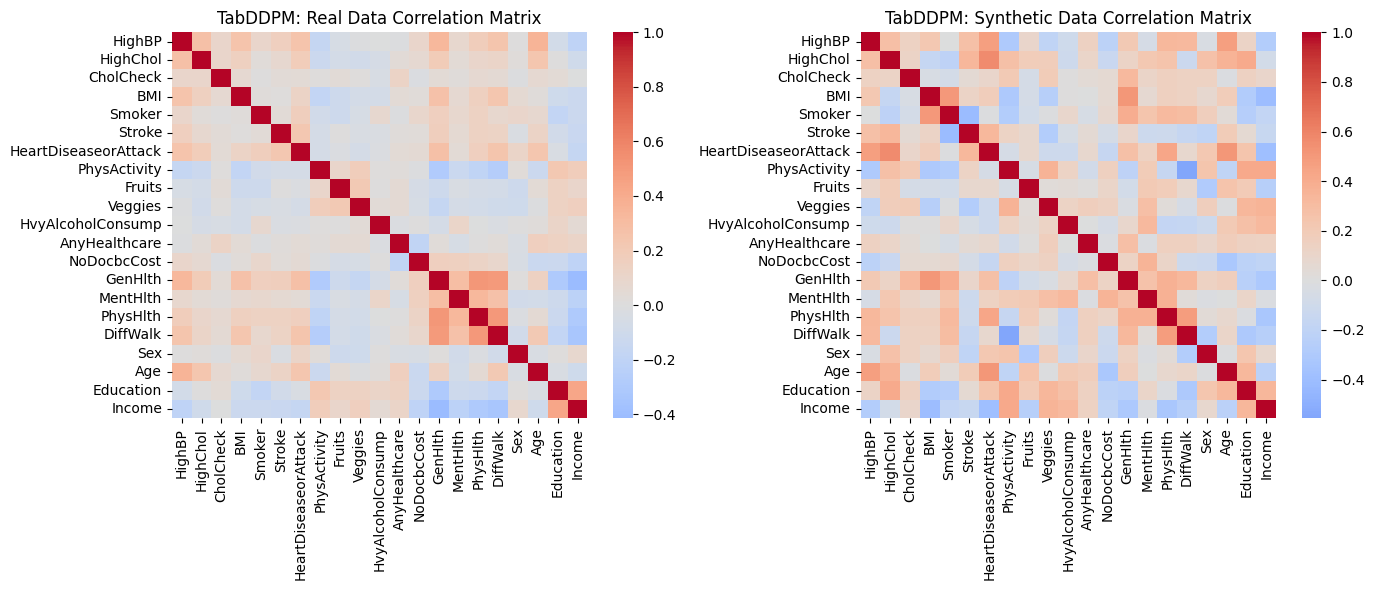

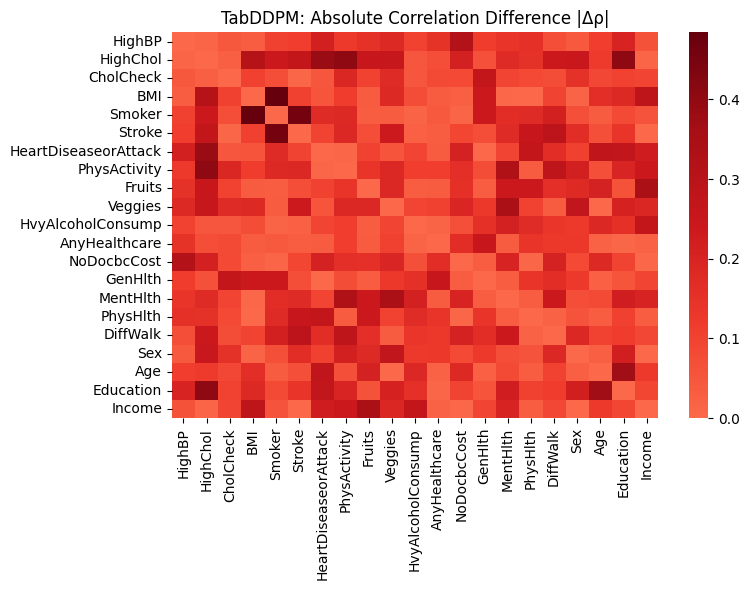

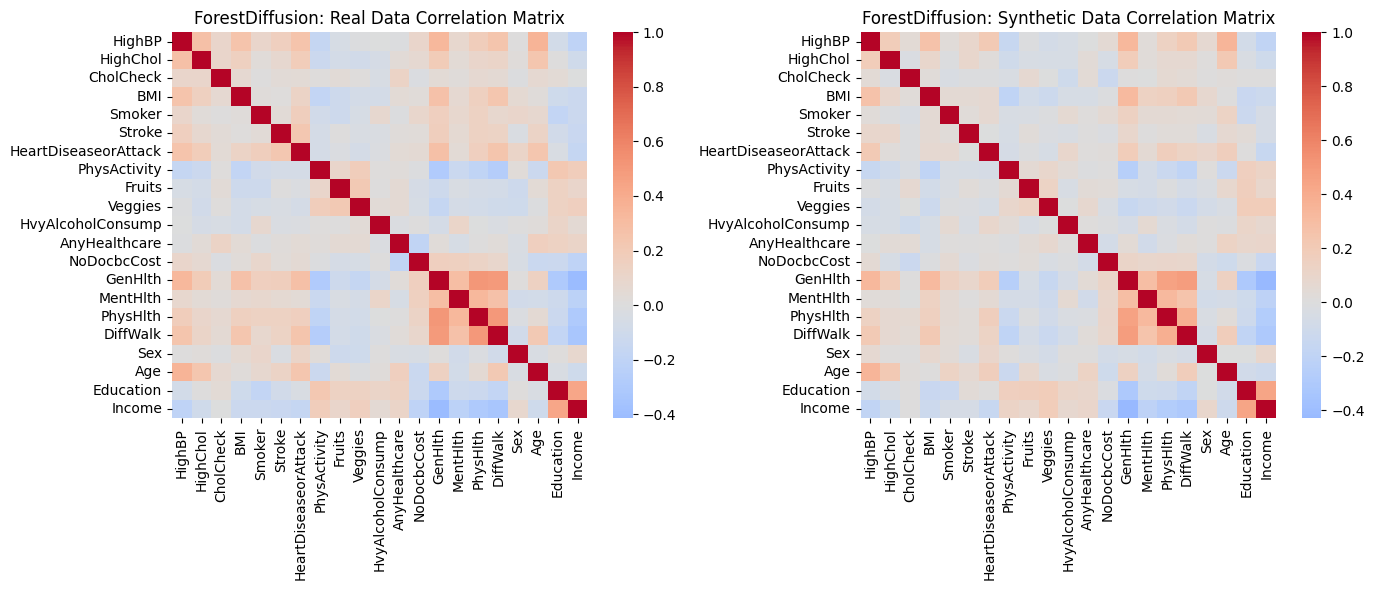

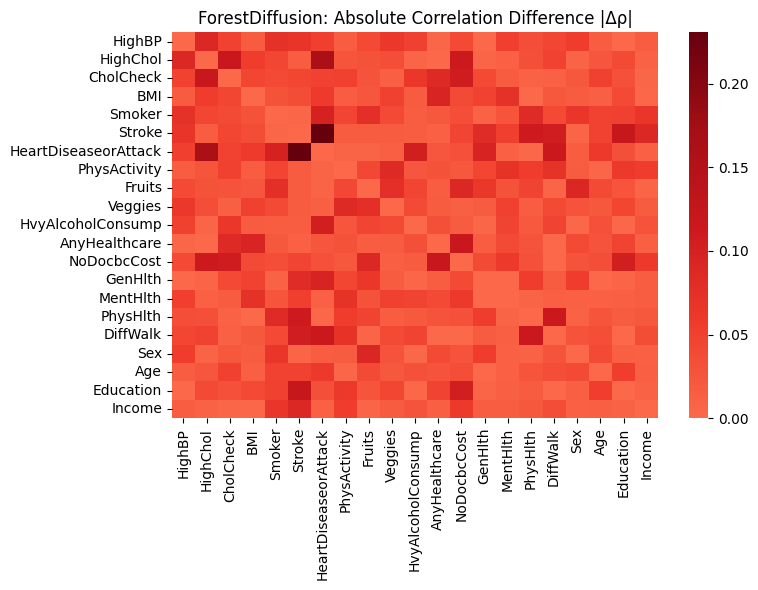

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "Diabetes_binary"
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

# remove target if it ended up in numeric columns
if target_col in num_cols:
    num_cols.remove(target_col)

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # align columns safely
    common_cols = real_df.columns.intersection(synth_df.columns)
    synth_df = synth_df[common_cols]

    # keep only numeric columns for correlation
    synth_num_cols = [c for c in num_cols if c in synth_df.columns]
    synth_corr = synth_df[synth_num_cols].corr()

    # make sure both matrices use the same order
    common_num_cols = [c for c in num_cols if c in synth_corr.columns]
    real_corr_plot = real_corr.loc[common_num_cols, common_num_cols]
    synth_corr_plot = synth_corr.loc[common_num_cols, common_num_cols]

    # 1) Real vs Synthetic correlation matrices
    fig, axes = plt.subplots(1, len(model_order), figsize=(14, 6))
    sns.heatmap(real_corr_plot, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr_plot, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    # 2) Absolute correlation difference heatmap
    diff_corr = (real_corr_plot - synth_corr_plot).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



TabDDPM - Global MMD (RBF): 0.303307


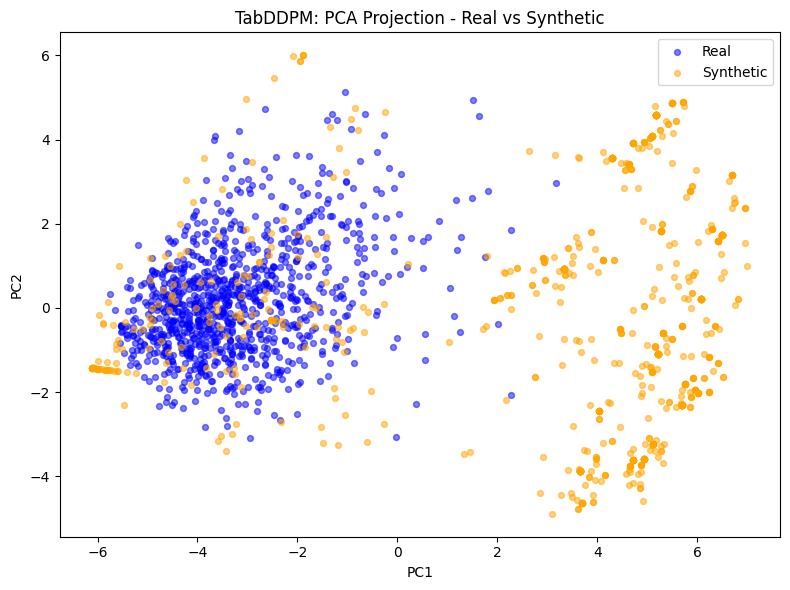

TabDDPM - Two-Sample Classifier Accuracy: 0.9650

ForestDiffusion - Global MMD (RBF): 0.001469


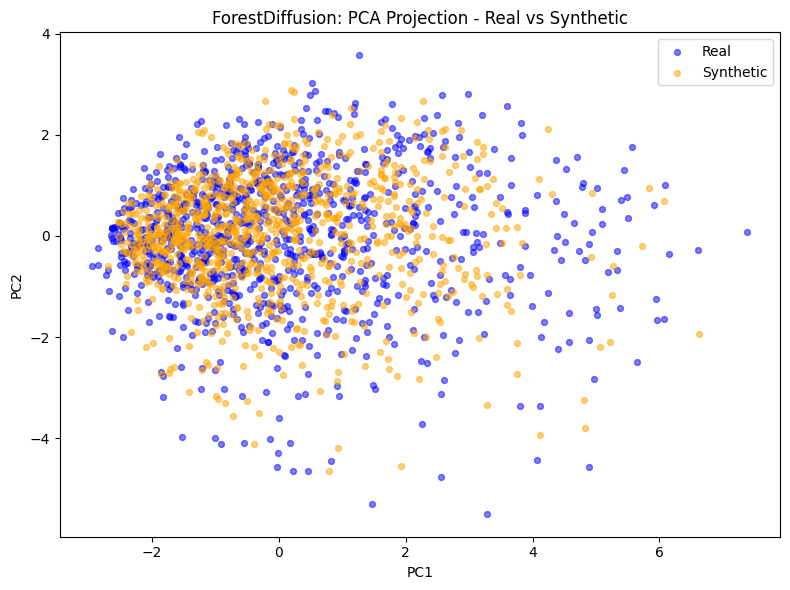

ForestDiffusion - Two-Sample Classifier Accuracy: 0.9750

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,ForestDiffusion,0.001469,0.975
1,TabDDPM,0.303307,0.965


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_order = ["TabDDPM", "ForestDiffusion"]

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
        med = np.median(dists[dists > 0])
        gamma = 1.0 / (2 * (med ** 2)) if med > 0 else 1.0
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

target_col = "Diabetes_binary"
X_real_df = data.drop(columns=[target_col], errors="ignore")
X_real_df = X_real_df.select_dtypes(include=[np.number])

results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.drop(columns=[target_col], errors="ignore")
    synth_df = synth_df.select_dtypes(include=[np.number])

    common_cols = X_real_df.columns.intersection(synth_df.columns)
    X_real = X_real_df[common_cols].values
    X_synth = synth_df[common_cols].values

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 classifiers

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


models = {

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

def evaluate_models(train_df, test_df, label_col, models=models, test_size=0.2, seed=42):
    def _coerce_class_labels(y):
        y = pd.to_numeric(pd.Series(y), errors="coerce").round()
        return y

    def _prepare_xy(df):
        df = df.copy()
        feature_cols = [c for c in df.columns if c != label_col]
        for col in feature_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        medians = df[feature_cols].median(numeric_only=True)
        for col in feature_cols:
            df[col] = df[col].fillna(medians[col])
        y = _coerce_class_labels(df[label_col])
        mask = y.notna()
        X = df.loc[mask, feature_cols].astype(np.float64)
        y = y.loc[mask].astype(int)
        return X, y

    X_train, y_train = _prepare_xy(train_df)
    X_test, y_test = _prepare_xy(test_df)

    common_cols = [c for c in X_train.columns if c in X_test.columns]
    X_train = X_train[common_cols]
    X_test = X_test[common_cols]

    strat_train = y_train if y_train.nunique() > 1 and y_train.value_counts().min() >= 2 else None
    strat_test = y_test if y_test.nunique() > 1 and y_test.value_counts().min() >= 2 else None

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=strat_train
    )
    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=strat_test
    )

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)
            if y_test.nunique() == 2:
                pos = 1 if 1 in clf.classes_ else clf.classes_[-1]
                pos_idx = list(clf.classes_).index(pos)
                auc = roc_auc_score(y_test, y_prob[:, pos_idx])
            else:
                auc = roc_auc_score(
                    y_test, y_prob, multi_class="ovr", average="weighted", labels=clf.classes_
                )
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            if scores.ndim == 1:
                y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
                auc = roc_auc_score(y_test, y_prob)
            else:
                auc = float("nan")
        else:
            auc = float("nan")

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False).reset_index(drop=True)


# The target column is 'Diabetes_binary'
label_col = "Diabetes_binary" # Directly set to the correct target column name
model_order = ["TabDDPM", "ForestDiffusion"]

data_eval = data.copy()

synthetic_eval = {}
for name, df in synthetic_outputs.items():
    tmp = df.copy()
    if label_col in tmp.columns:
        tmp[label_col] = pd.to_numeric(tmp[label_col], errors="coerce").round()
        tmp = tmp.dropna(subset=[label_col])
        tmp[label_col] = tmp[label_col].astype(int)
    synthetic_eval[name] = tmp

data_eval[label_col] = pd.to_numeric(data_eval[label_col], errors="coerce").round()
data_eval = data_eval.dropna(subset=[label_col])
data_eval[label_col] = pd.to_numeric(data_eval[label_col], errors="coerce").round().astype(int)

data_eval[label_col] = pd.to_numeric(data_eval[label_col], errors="coerce").round()
data_eval = data_eval.dropna(subset=[label_col])
data_eval[label_col] = pd.to_numeric(data_eval[label_col], errors="coerce").round().astype(int)

# Identify all categorical columns (excluding the target column which is already numeric)
categorical_features = [col for col in data_eval.columns if data_eval[col].dtype == 'object' and col != label_col]

# Store label encoders for consistent transformation across real and synthetic data
label_encoders_for_eval = {}

for col in categorical_features:
    # Collect all unique categories from real and all synthetic datasets for the current column
    all_categories_for_col = pd.Series(dtype='object')
    all_categories_for_col = pd.concat([all_categories_for_col, data_eval[col].astype(str)])
    for name in synthetic_eval:
        if col in synthetic_eval[name].columns:
            all_categories_for_col = pd.concat([all_categories_for_col, synthetic_eval[name][col].astype(str)])
    all_categories_for_col = all_categories_for_col.unique()

    # Fit a LabelEncoder on all collected unique categories
    le = LabelEncoder()
    le.fit(all_categories_for_col)
    label_encoders_for_eval[col] = le

    # Transform the column in the real data_eval dataframe
    data_eval[col] = le.transform(data_eval[col].astype(str))

    # Transform the column in all synthetic_eval dataframes
    for name in synthetic_eval:
        if col in synthetic_eval[name].columns:
            synthetic_eval[name][col] = le.transform(synthetic_eval[name][col].astype(str))

all_possible_labels = sorted(
    pd.to_numeric(
        pd.concat(
            [data_eval[label_col]]
            + [df[label_col] for df in synthetic_eval.values() if label_col in df.columns],
            ignore_index=True,
        ),
        errors="coerce",
    ).dropna().astype(int).unique().tolist()
)

trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_eval[synth_name],
        test_df=data_eval,
        label_col=label_col,
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
0,AdaBoost,0.840,0.819824,0.802398
1,LogReg,0.870,0.840714,0.782060
2,RandomForest,0.855,0.819417,0.751873
3,ExtraTrees,0.850,0.802921,0.745986
4,GradientBoost,0.830,0.808563,0.735174
5,NaiveBayes,0.720,0.755478,0.714836
6,KNN,0.835,0.800958,0.684329
7,MLP,0.785,0.783281,0.646971
8,SVM-RBF,0.865,0.811359,0.637337
9,DecisionTree,0.820,0.813829,0.583387


TabDDPM - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,F1,AUC
0,DecisionTree,0.715,0.747418,0.569578
1,GradientBoost,0.805,0.783062,0.525797
2,RandomForest,0.860,0.799892,0.513380
3,NaiveBayes,0.865,0.802386,0.509099
4,MLP,0.805,0.787972,0.497752
5,KNN,0.860,0.799892,0.474845
6,ExtraTrees,0.850,0.794865,0.439199
7,SVM-RBF,0.865,0.802386,0.436737
8,LogReg,0.865,0.802386,0.389210
9,AdaBoost,0.865,0.802386,0.379148


TabDDPM - TRTR vs TSTR Comparison


...

,Model,Accuracy,F1,AUC
0,LogReg,0.835,0.836261,0.790195
1,MLP,0.795,0.804646,0.786769
2,AdaBoost,0.805,0.806490,0.776707
3,ExtraTrees,0.850,0.821736,0.767609
4,RandomForest,0.835,0.833681,0.758189
5,SVM-RBF,0.865,0.825908,0.746521
6,GradientBoost,0.800,0.810536,0.742453
7,NaiveBayes,0.390,0.435304,0.729180
8,KNN,0.850,0.821736,0.687326
9,DecisionTree,0.720,0.751020,0.572468


ForestDiffusion - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Synthetic_Model
0,AdaBoost,0.840,0.819824,0.802398,0.805,0.806490,0.776707,0.025690,0.013334,0.035,ForestDiffusion
9,DecisionTree,0.820,0.813829,0.583387,0.720,0.751020,0.572468,0.010918,0.062808,0.100,ForestDiffusion
6,KNN,0.835,0.800958,0.684329,0.850,0.821736,0.687326,-0.002997,-0.020778,-0.015,ForestDiffusion
2,RandomForest,0.855,0.819417,0.751873,0.835,0.833681,0.758189,-0.006316,-0.014264,0.020,ForestDiffusion
4,GradientBoost,0.830,0.808563,0.735174,0.800,0.810536,0.742453,-0.007279,-0.001973,0.030,ForestDiffusion
1,LogReg,0.870,0.840714,0.782060,0.835,0.836261,0.790195,-0.008135,0.004453,0.035,ForestDiffusion
5,NaiveBayes,0.720,0.755478,0.714836,0.390,0.435304,0.729180,-0.014344,0.320173,0.330,ForestDiffusion
3,ExtraTrees,0.850,0.802921,0.745986,0.850,0.821736,0.767609,-0.021623,-0.018815,0.000,ForestDiffusion
8,SVM-RBF,0.865,0.811359,0.637337,0.865,0.825908,0.746521,-0.109184,-0.014549,0.000,ForestDiffusion
7,MLP,0.785,0.783281,0.646971,0.795,0.804646,0.786769,-0.139799,-0.021364,-0.010,ForestDiffusion


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
0,ForestDiffusion,-0.027307
1,TabDDPM,0.234960



TabDDPM - TSTR

ForestDiffusion - TSTR


,Model,Accuracy,F1,AUC
0,LogReg,0.835,0.836261,0.790195
1,MLP,0.795,0.804646,0.786769
2,AdaBoost,0.805,0.806490,0.776707
3,ExtraTrees,0.850,0.821736,0.767609
4,RandomForest,0.835,0.833681,0.758189
5,SVM-RBF,0.865,0.825908,0.746521
6,GradientBoost,0.800,0.810536,0.742453
7,NaiveBayes,0.390,0.435304,0.729180
8,KNN,0.850,0.821736,0.687326
9,DecisionTree,0.720,0.751020,0.572468


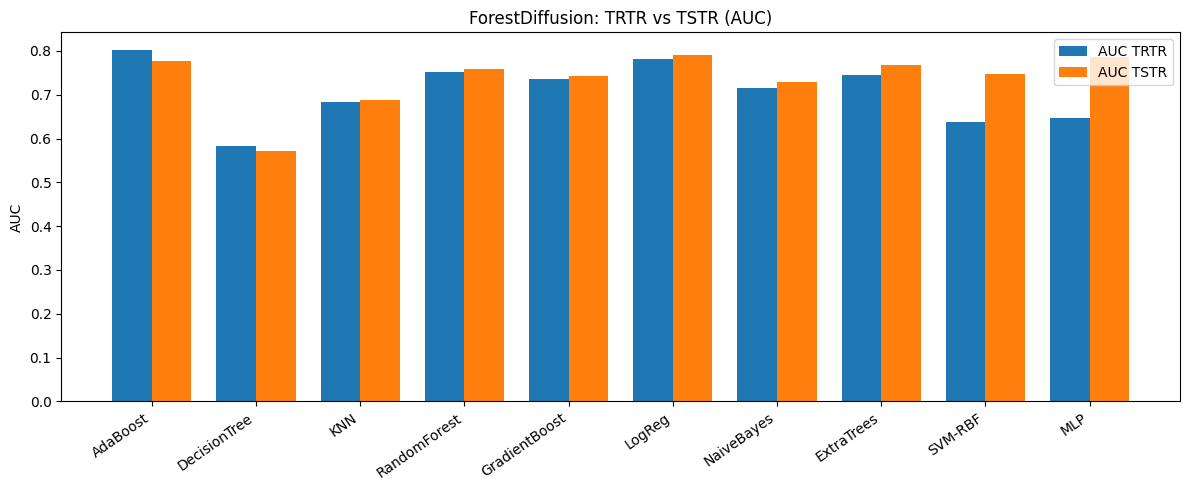

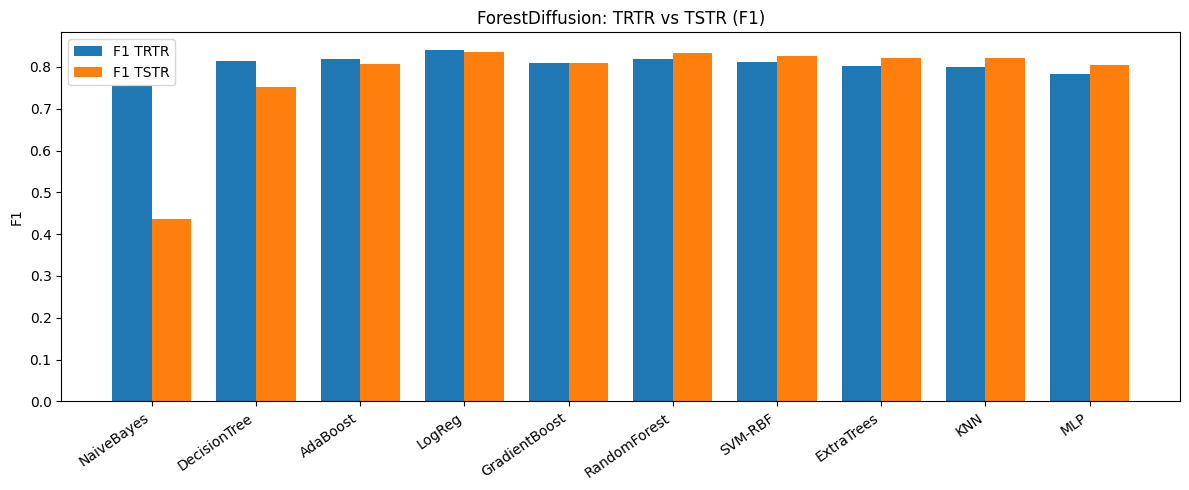

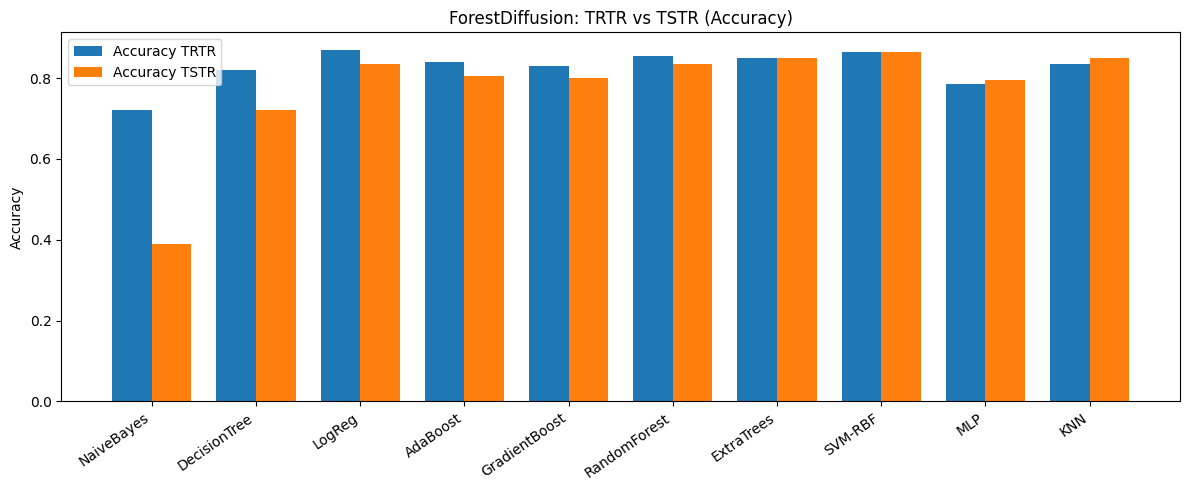

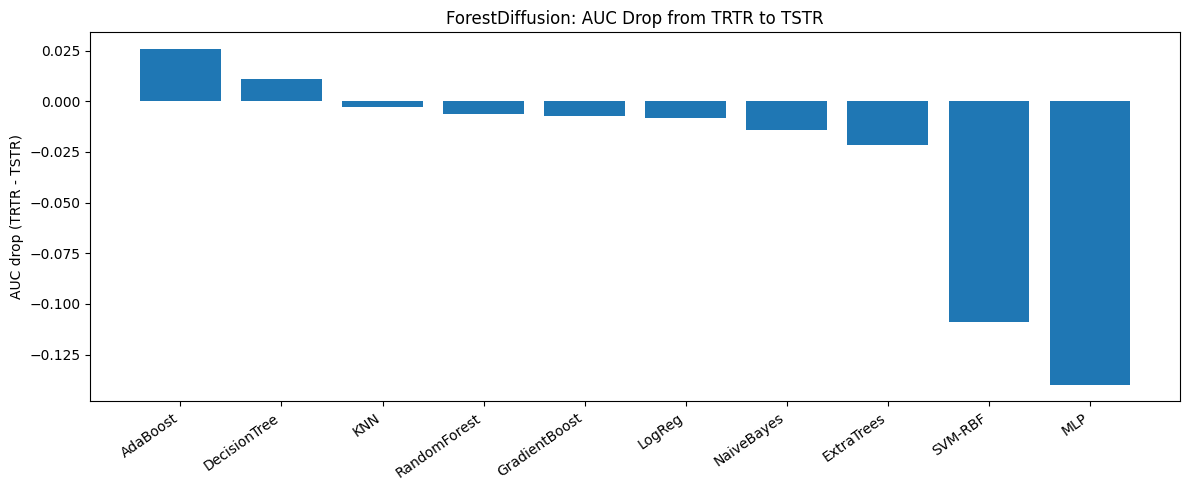


Average AUC drop by synthetic generator:


,Synthetic_Model,AUC_Drop
0,ForestDiffusion,-0.027307
1,TabDDPM,0.234960


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=["_TRTR", "_TSTR"]
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

# label_col for CDC diabetes classification
label_col = "Diabetes_binary"
model_order = ["TabDDPM", "ForestDiffusion"]

data_eval = data.copy()
# Ensure Diabetes_binary is integer
if label_col in data_eval.columns:
    data_eval[label_col] = pd.to_numeric(data_eval[label_col], errors="coerce").round().astype(int)

synthetic_eval = {}
for name in model_order:
    df = synthetic_outputs[name].copy()
    # Coerce Diabetes_binary in synthetic data
    if label_col in df.columns:
        df[label_col] = pd.to_numeric(df[label_col], errors="coerce").round().astype(int)
    synthetic_eval[name] = df

# Identify all categorical columns (excluding the target column which is already numeric)
categorical_features = [col for col in data_eval.columns if data_eval[col].dtype == 'object' and col != label_col]

# Store label encoders for consistent transformation across real and synthetic data
label_encoders_for_eval = {}

for col in categorical_features:
    # Collect all unique categories from real and all synthetic datasets for the current column
    all_categories_for_col = pd.Series(dtype='object')
    all_categories_for_col = pd.concat([all_categories_for_col, data_eval[col].astype(str)])
    for name in model_order:
        if col in synthetic_eval[name].columns:
            all_categories_for_col = pd.concat([all_categories_for_col, synthetic_eval[name][col].astype(str)])
    all_categories_for_col = all_categories_for_col.unique()

    # Fit a LabelEncoder on all collected unique categories
    le = LabelEncoder()
    le.fit(all_categories_for_col)
    label_encoders_for_eval[col] = le

    # Transform the column in the real data_eval dataframe
    data_eval[col] = le.transform(data_eval[col].astype(str))

    # Transform the column in all synthetic_eval dataframes
    for name in model_order:
        if col in synthetic_eval[name].columns:
            synthetic_eval[name][col] = le.transform(synthetic_eval[name][col].astype(str))


trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label_col=label_col,
    models=models
)

all_comp = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_eval[synth_name],
        test_df=data_eval,
        label_col=label_col,
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=["_TRTR", "_TSTR"]
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
display(tstr_results)

for metric in ["AUC", "F1", "Accuracy"]:
    plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

plot_auc_drop(comparison, synth_name)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_auc = (
    combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("\nAverage AUC drop by synthetic generator:")
display(summary_auc)

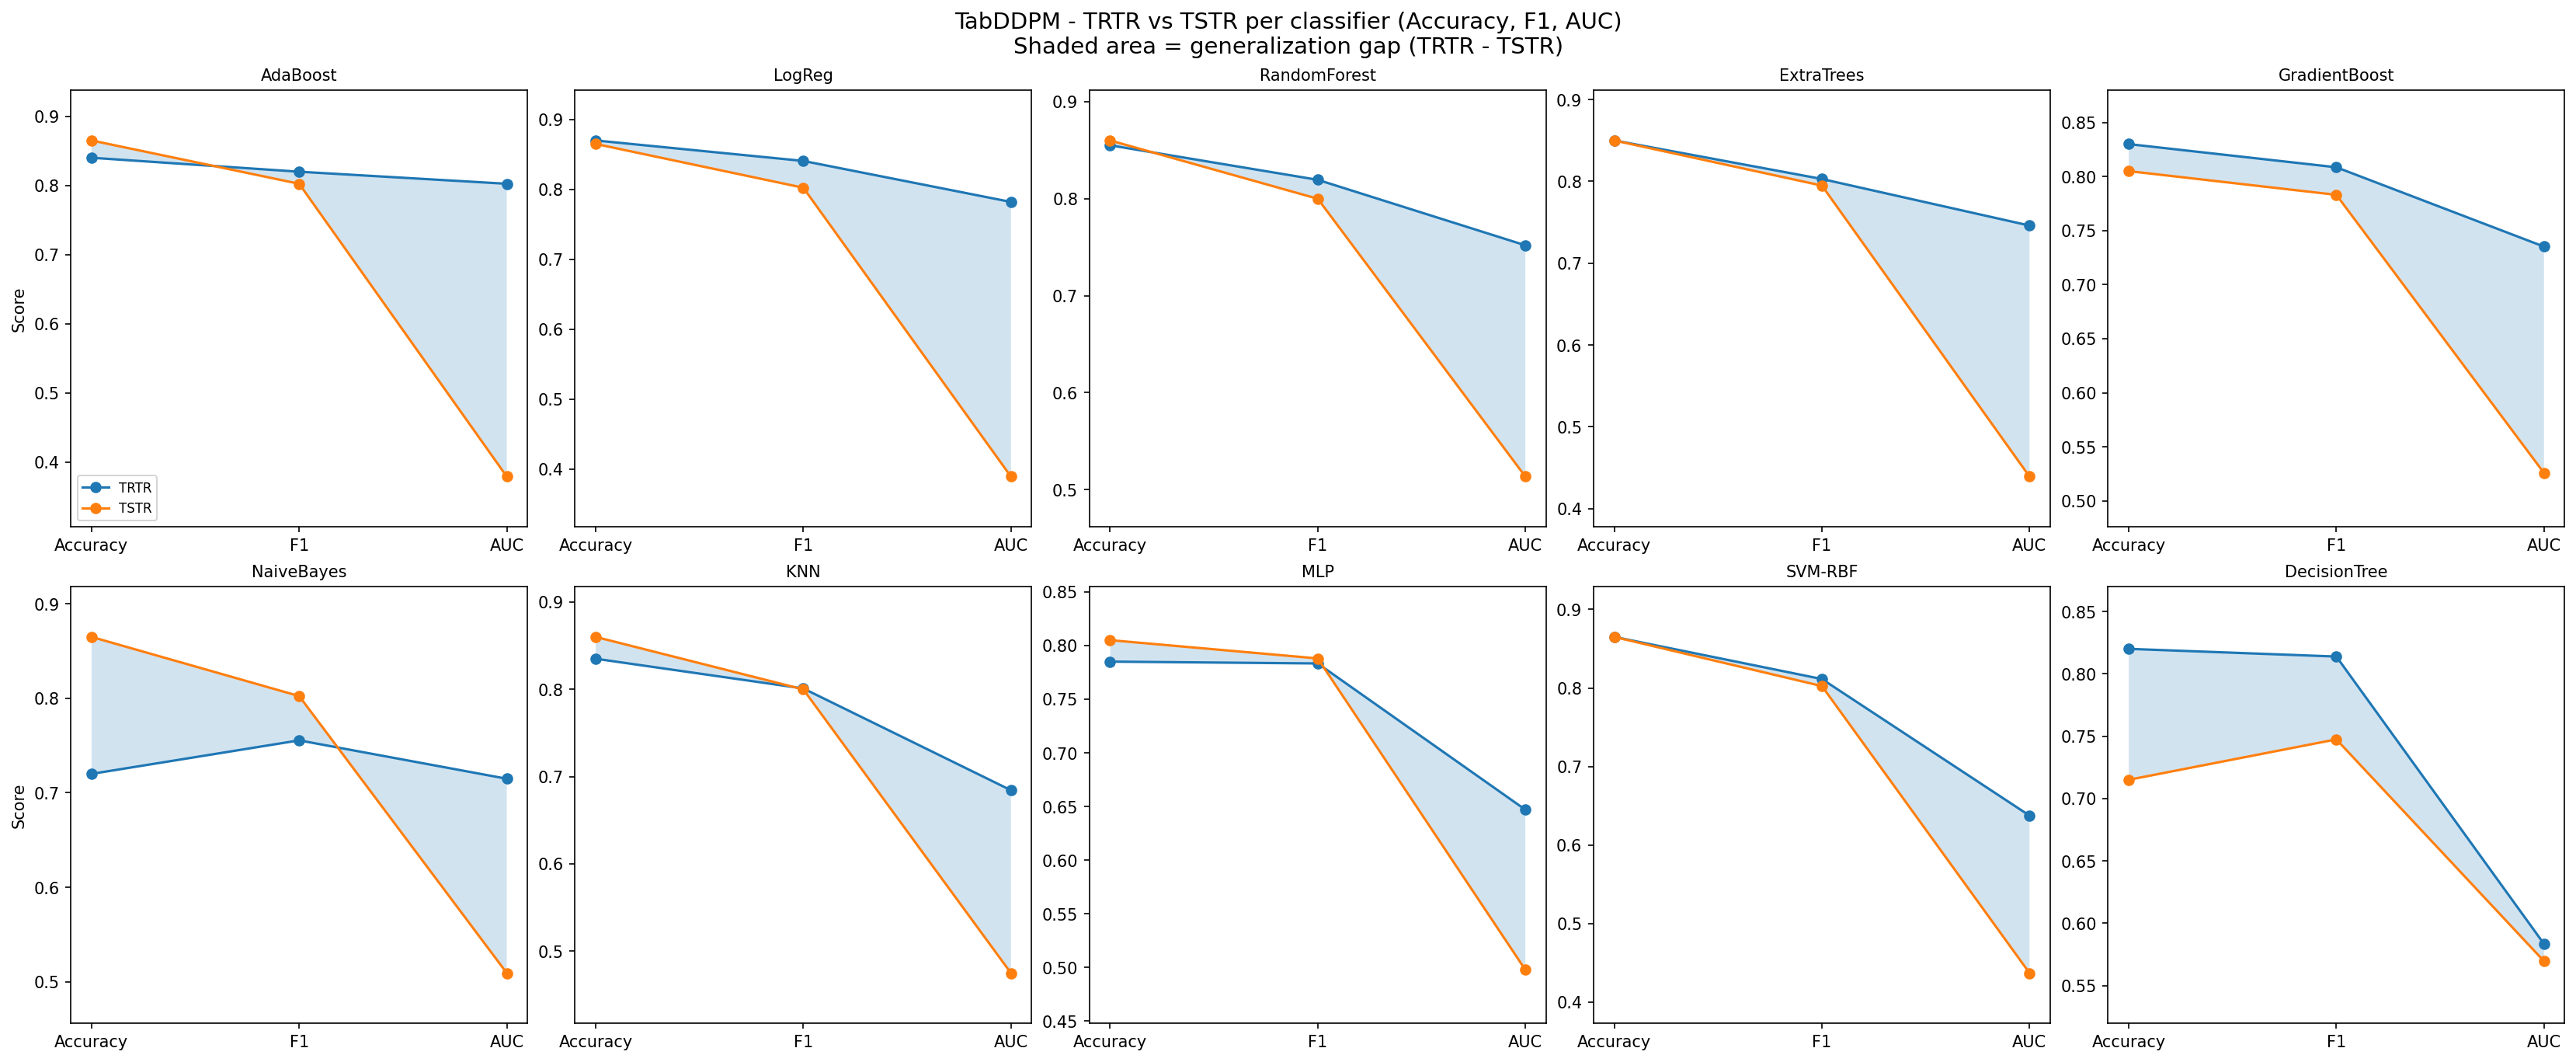

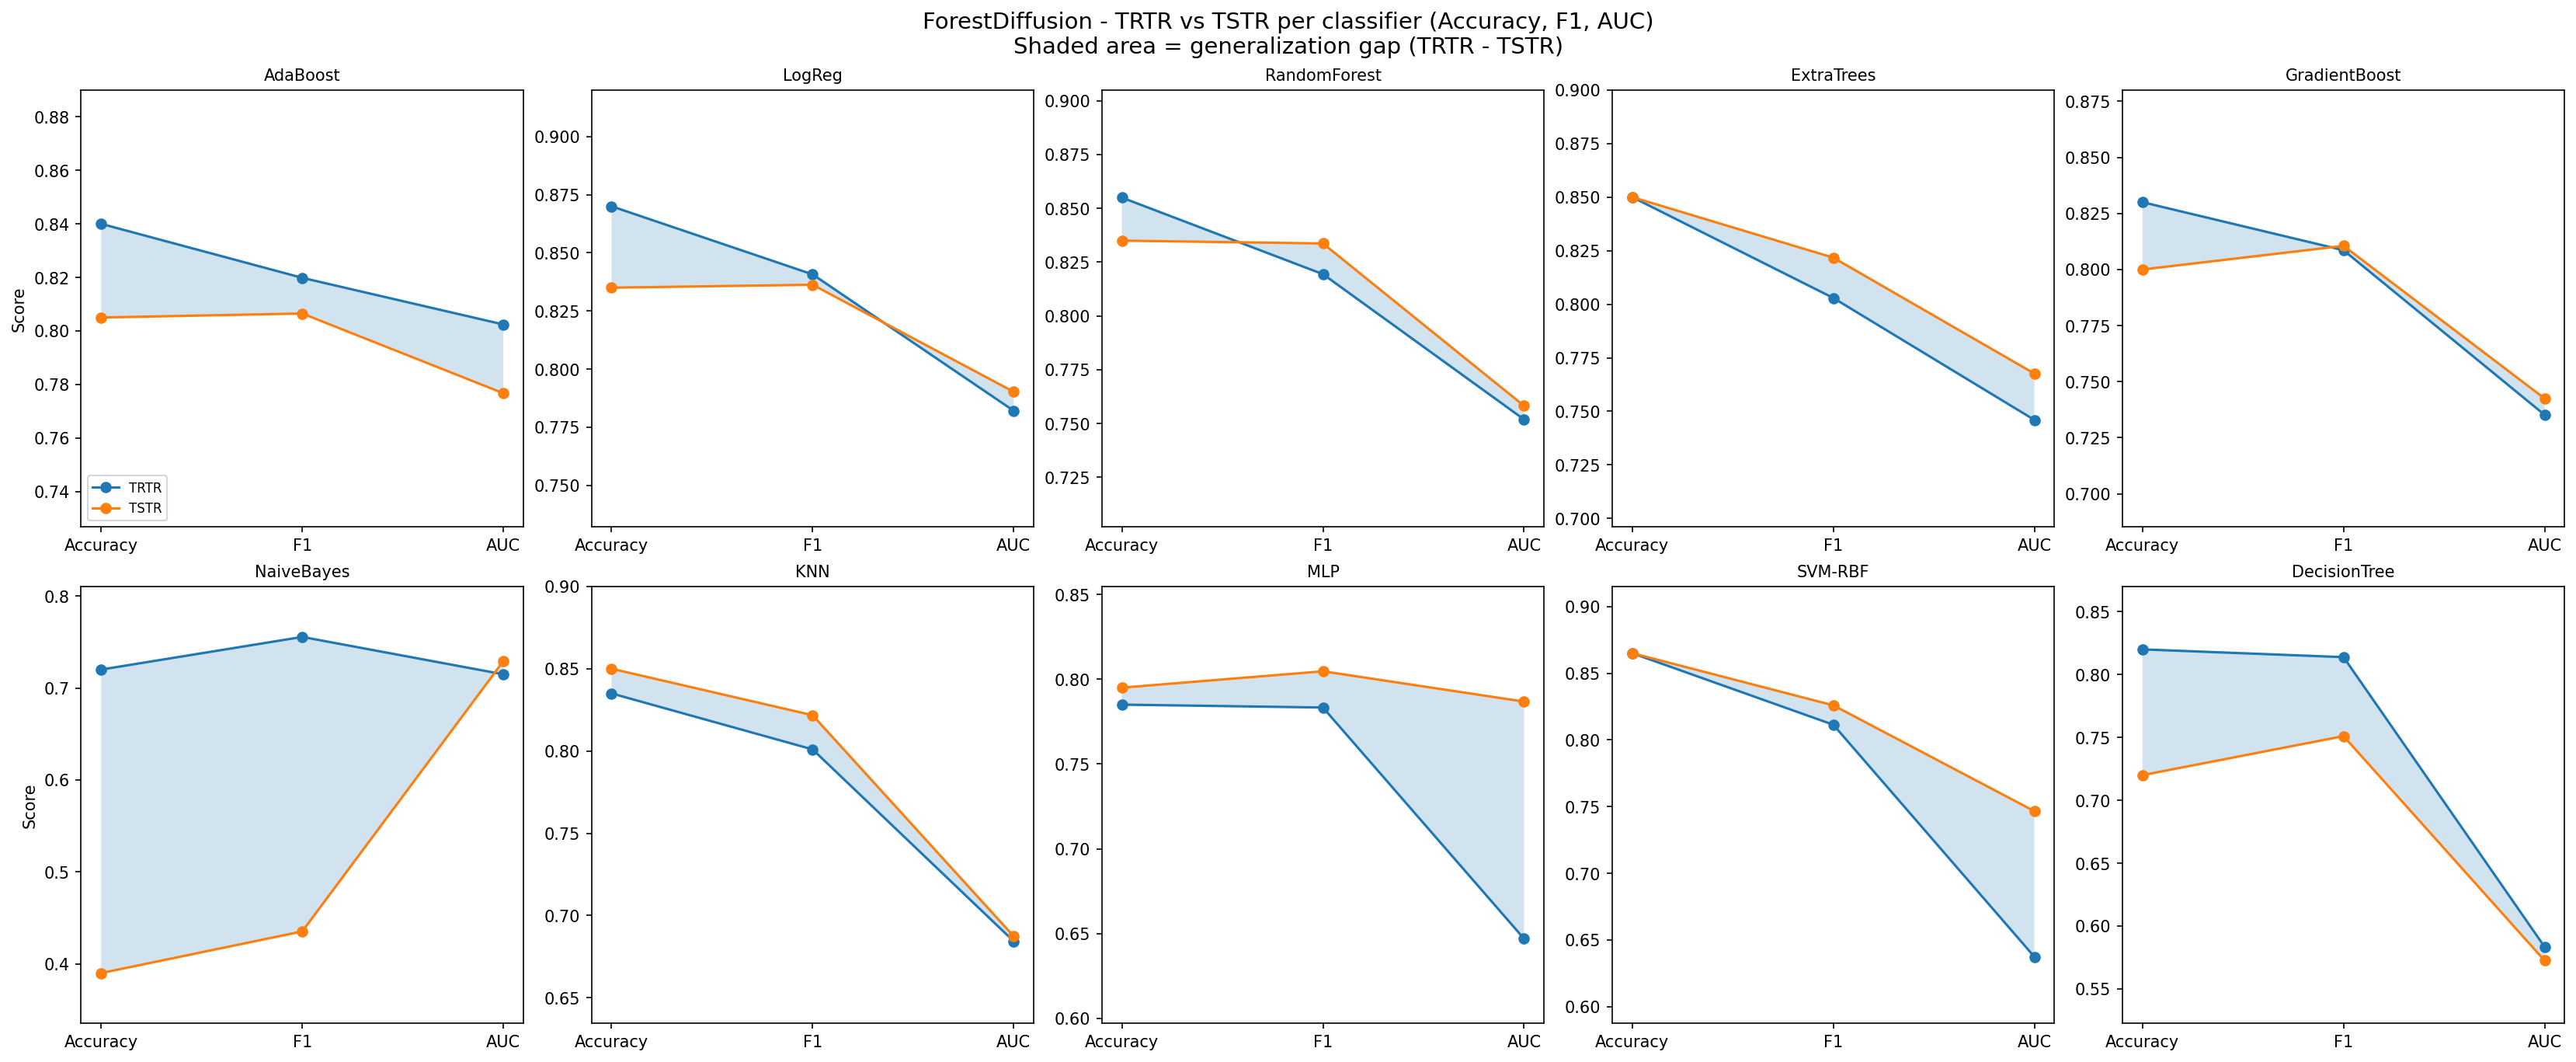

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "Diabetes_binary"
generators = ["TabDDPM", "ForestDiffusion"]

data_eval = data.copy()
# Ensure real target is integer
data_eval[label_col] = pd.to_numeric(data_eval[label_col], errors="coerce").round().astype(int)

synthetic_eval_processed = {}
for name in generators:
    tmp = synthetic_outputs[name].copy()
    # FIX: Ensure synthetic target is rounded and converted to integer for classification
    if label_col in tmp.columns:
        tmp[label_col] = pd.to_numeric(tmp[label_col], errors="coerce").round()
        tmp = tmp.dropna(subset=[label_col])
        tmp[label_col] = tmp[label_col].astype(int)
    synthetic_eval_processed[name] = tmp

# Identify all categorical columns
categorical_features = [col for col in data_eval.columns if data_eval[col].dtype == 'object' and col != label_col]

# Store label encoders
label_encoders_for_eval = {}

for col in categorical_features:
    all_categories_for_col = pd.Series(dtype='object')
    all_categories_for_col = pd.concat([all_categories_for_col, data_eval[col].astype(str)])
    for name in generators:
        if col in synthetic_eval_processed[name].columns:
            all_categories_for_col = pd.concat([all_categories_for_col, synthetic_eval_processed[name][col].astype(str)])
    all_categories_for_col = all_categories_for_col.unique()

    le = LabelEncoder()
    le.fit(all_categories_for_col)
    label_encoders_for_eval[col] = le

    data_eval[col] = le.transform(data_eval[col].astype(str))
    for name in generators:
        if col in synthetic_eval_processed[name].columns:
            synthetic_eval_processed[name][col] = le.transform(synthetic_eval_processed[name][col].astype(str))

# Note: ensure 'evaluate_models' cell and 'all_possible_labels' are defined by running cell SkFC-Dh0Q2fz first.
trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label_col=label_col,
    models=models
)

for gen in generators:
    tstr_results = evaluate_models(
        train_df=synthetic_eval_processed[gen],
        test_df=data_eval,
        label_col=label_col,
        models=models
    )

    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )

# 5 Statistical similarity tests

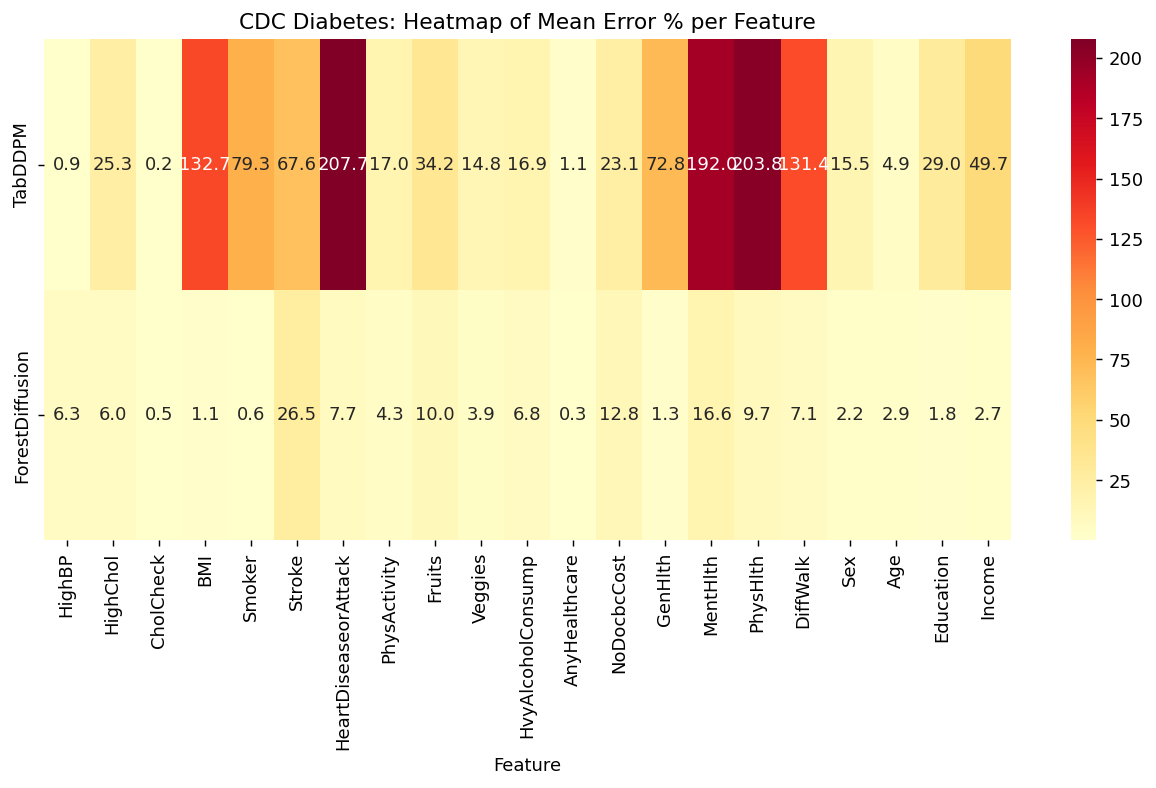

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-ensure model_order and feature_error_by_model exist
model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "Diabetes_binary"
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

feature_error_by_model = {}
for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    real_means, synth_means = real_df[num_cols].mean(), synth_df[num_cols].mean()
    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    feature_error_by_model[model_name] = pd.DataFrame({"Feature": num_cols, "Mean_Error_%": mean_error_pct.values})

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T.replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(12, 5), dpi=130)
sns.heatmap(heatmap_df, cmap="YlOrRd", annot=True, fmt=".1f")
plt.title("CDC Diabetes: Heatmap of Mean Error % per Feature")
plt.show()

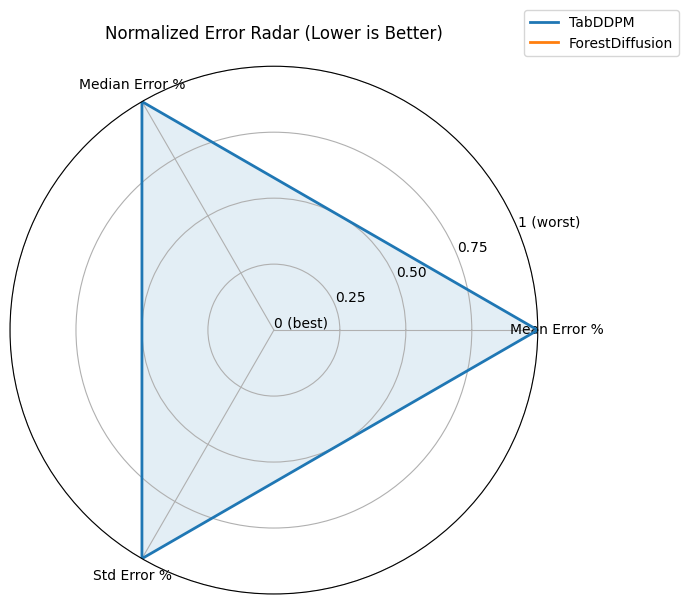

,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,62.860091,29.042448,42.468087
1,ForestDiffusion,6.246075,4.342105,8.990569


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Re-calculate the necessary metrics to avoid NameErrors
model_order = ["TabDDPM", "ForestDiffusion"]

def _coerce_numeric_features(df, cols):
    out = df[cols].copy()
    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out
target_col = "Diabetes_binary"
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

feature_error_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    real_num = _coerce_numeric_features(real_df, num_cols)
    synth_num = _coerce_numeric_features(synth_df, num_cols)
    real_means = real_num.mean()
    synth_means = synth_num.mean()
    real_stds = real_df[num_cols].std()
    synth_stds = synth_df[num_cols].std()

    # Calculate errors
    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_by_model[model_name] = feature_error_df

    summary_rows.append({
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    })

summary_df = pd.DataFrame(summary_rows)

# 2. Generate the Radar Plot
metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

# Min-max normalize each metric across models (0 = best, 1 = worst)
norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))
plt.tight_layout()
plt.show()

display(summary_df)


Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,ForestDiffusion,10.809524,9.0,33
1,TabDDPM,80.857143,23.0,240


/tmp/ipykernel_2431845/3583294308.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")


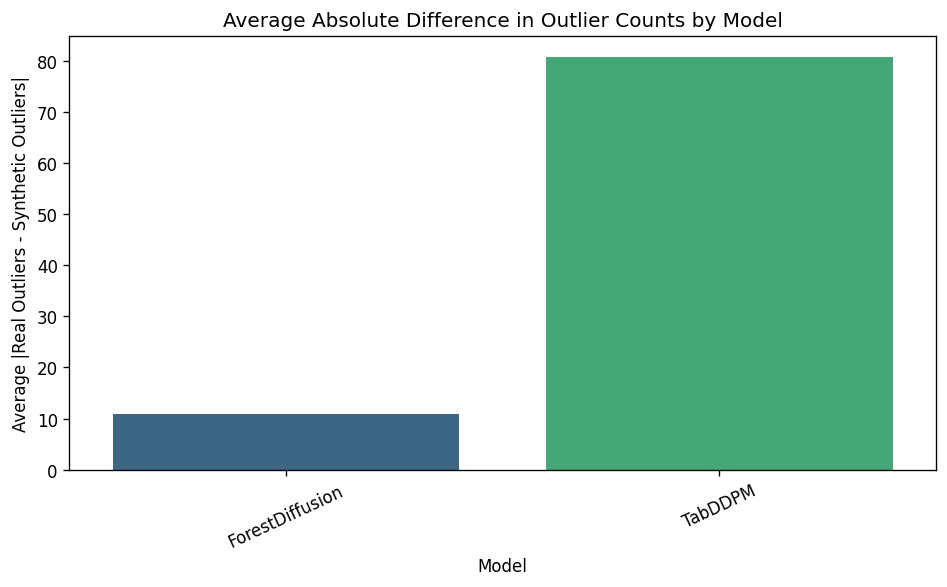

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "Diabetes_binary"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_outputs[model].copy()

    # keep only shared columns and numeric features
    common_cols = real_df.columns.intersection(synth_df.columns)
    synth_df = synth_df[common_cols]
    synth_num_cols = [c for c in num_cols if c in synth_df.columns]

    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in synth_num_cols}

    feat_df = pd.DataFrame({
        "Feature": synth_num_cols,
        "Real_Outliers": [real_outliers[c] for c in synth_num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in synth_num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max()
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# 6. Cosine Similarity with Hungraian Mapping

In [27]:
from numpy.linalg import norm
import numpy as np
import pandas as pd

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def cosine_similarity_matrix(real_df, synth_df, num_cols=None, target_col=None):
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col is None:
        target_col = "Diabetes_binary"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

# Map your synthetic outputs here
synthetic_data = {
    "ForestDiffusion": synthetic_outputs["ForestDiffusion"],
    "TabDDPM": synthetic_outputs["TabDDPM"]
}

cosine_results = {}
cosine_dfs = {}

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "Diabetes_binary" # Corrected to Diabetes_binary as per overall context
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = normalize_rows(data[num_cols].to_numpy(dtype=float))

for model_name in model_order:
    if model_name not in synthetic_data:
        raise KeyError(f"{model_name} not found in synthetic_data. Available keys: {list(synthetic_data.keys())}")

    synth_df = synthetic_data[model_name].copy()

    missing_cols = [c for c in data.columns if c not in synth_df.columns]
    if missing_cols:
        raise ValueError(f"{model_name} is missing columns: {missing_cols}")

    synth_df = synth_df[data.columns].copy()
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy(dtype=float))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)


Building cosine similarity DataFrame for TabDDPM...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.846904  0.904022  0.666212  0.895710  0.843625  0.906060  0.895141   
R2   0.953874  0.864243  0.903668  0.833303  0.970090  0.874505  0.833303   
R3   0.868391  0.830539  0.554919  0.807693  0.775532  0.838386  0.807693   
R4   0.862843  0.937204  0.616179  0.886166  0.875132  0.960175  0.885749   
R5   0.911218  0.978838  0.680305  0.978439  0.925565  0.972162  0.978439   
R6   0.885428  0.960089  0.655596  0.942310  0.896849  0.962863  0.941933   
R7   0.903366  0.982709  0.624419  0.949045  0.917953  0.993796  0.949045   
R8   0.886243  0.888065  0.623957  0.874361  0.828853  0.889899  0.873931   
R9   0.900060  0.977329  0.655506  0.986589  0.912601  0.965581  0.986181   
R10  0.902762  0.807017  0.626130  0.792976  0.803672  0.808779  0.792614   

           S8        S9       S10  
R1   0.718356  0.903874  0.928913  
R2   0.588784  0.864393  0.8

,avg_cosine,max_cosine
TabDDPM,0.864379,0.999979
ForestDiffusion,0.913188,0.999960


In [28]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    target_col = "Diabetes_binary"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")



ForestDiffusion - Top 10 Real -> Synthetic Matchings
01. R220 -> S849   cosine similarity = 1.0000
02. R719 -> S199   cosine similarity = 0.9999
03. R955 -> S24   cosine similarity = 0.9999
04. R563 -> S374   cosine similarity = 0.9999
05. R620 -> S322   cosine similarity = 0.9999
06. R531 -> S715   cosine similarity = 0.9998
07. R58 -> S445   cosine similarity = 0.9998
08. R372 -> S699   cosine similarity = 0.9998
09. R128 -> S70   cosine similarity = 0.9998
10. R231 -> S199   cosine similarity = 0.9998

TabDDPM - Top 10 Real -> Synthetic Matchings
01. R688 -> S357   cosine similarity = 1.0000
02. R427 -> S193   cosine similarity = 0.9997
03. R531 -> S357   cosine similarity = 0.9995
04. R563 -> S857   cosine similarity = 0.9994
05. R314 -> S193   cosine similarity = 0.9994
06. R631 -> S623   cosine similarity = 0.9994
07. R174 -> S998   cosine similarity = 0.9994
08. R486 -> S193   cosine similarity = 0.9993
09. R380 -> S193   cosine similarity = 0.9992
10. R269 -> S672   cosine sim

In [29]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    target_col = "Diabetes_binary"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()

# Use your actual synthetic DataFrames here
# Use TabDDPM and ForestDiffusion synthetic outputs
synthetic_data = {
    "ForestDiffusion": synthetic_outputs["ForestDiffusion"],
    "TabDDPM": synthetic_outputs["TabDDPM"],
}

results = {}

for name, synth_df in synthetic_data.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features)")
    print(f"==============================")

    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common].copy()

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")

summary_df = pd.DataFrame(
    [{"Model": name, "Avg_Hungarian_Cosine": info["avg_similarity"]} for name, info in results.items()]
).sort_values("Avg_Hungarian_Cosine", ascending=False)

display(summary_df)



ForestDiffusion: Hungarian matching (cosine, numeric features)
Average cosine similarity (Hungarian match): 0.9947

R220 <-> S849   cosine similarity = 1.0000
R955 <-> S24   cosine similarity = 0.9999
R563 <-> S374   cosine similarity = 0.9999
R620 <-> S322   cosine similarity = 0.9999
R531 <-> S715   cosine similarity = 0.9998
R372 <-> S699   cosine similarity = 0.9998
R128 <-> S70   cosine similarity = 0.9998
R231 <-> S199   cosine similarity = 0.9998
R998 <-> S764   cosine similarity = 0.9998
R667 <-> S934   cosine similarity = 0.9998

TabDDPM: Hungarian matching (cosine, numeric features)
Average cosine similarity (Hungarian match): 0.9434

R764 <-> S717   cosine similarity = 0.9992
R68 <-> S672   cosine similarity = 0.9973
R338 <-> S516   cosine similarity = 0.9971
R131 <-> S844   cosine similarity = 0.9970
R446 <-> S193   cosine similarity = 0.9967
R542 <-> S391   cosine similarity = 0.9966
R354 <-> S990   cosine similarity = 0.9965
R604 <-> S339   cosine similarity = 0.9965
R49

,Model,Avg_Hungarian_Cosine
0,ForestDiffusion,0.994654
1,TabDDPM,0.943439


In [30]:
import pandas as pd
import numpy as np

# Install xlsxwriter if not already installed
!pip install xlsxwriter

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

target_col = "Diabetes_binary"
if target_col in feature_cols:
    feature_cols.remove(target_col)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

model_order = ["TabDDPM", "ForestDiffusion"]  # ← FIXED: Match your results keys
output_file = "Hungarian_Matchings_All_Models.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            print(f"Skipping {model_name}: no Hungarian results found")
            continue
        if model_name not in synth_source:
            print(f"Skipping {model_name}: no synthetic data found")
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        display(summary_df)  # ← FIXED: Moved inside with block

print(f"Saved: {output_file}")


,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
1,ForestDiffusion,1000,0.994654,0.996847,0.956033,0.999960
0,TabDDPM,1000,0.943439,0.954204,0.817356,0.999166


Saved: Hungarian_Matchings_All_Models.xlsx


# 7. Mahalanobis distance with Hungrain Mapping  

In [31]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

target_col = "Diabetes_binary"

data_numeric = data.select_dtypes(include=[np.number]).dropna().copy()
if target_col in data_numeric.columns:
    data_numeric = data_numeric.drop(columns=[target_col])

real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (21,), Inv_cov shape: (21, 21)


In [32]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

# 1. Define target and features FIRST to ensure consistent dimensions
target_col = "Diabetes_binary"
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

# 2. Compute real distribution statistics using the correct feature subset
real_numeric = data[num_cols].to_numpy(dtype=float)
mu_real = np.mean(real_numeric, axis=0)
cov_real = np.cov(real_numeric, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))  # Stabilize

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found.")

mahalanobis_results = {}
available_models = []

for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source:
        # Ensure we use the exact same columns for the synthetic data
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        # Compute Mahalanobis distances (dimensions now match: 11 vs 11)
        dists = [mahalanobis(x, mu_real, inv_cov_real) for x in synth_numeric]
        dists = np.array(dists)

        mahalanobis_results[name] = {
            "mean": float(np.mean(dists)),
            "median": float(np.median(dists)),
            "std": float(np.std(dists)),
            "min": float(np.min(dists)),
            "max": float(np.max(dists)),
            "distances": dists,
        }
        available_models.append(name)
        print(f"✓ {name}: mean Mahalanobis = {np.mean(dists):.3f}")
    else:
        print(f"✗ {name} not found in synthetic source.")

# Create summary only for available models
if mahalanobis_results:
    summary = pd.DataFrame({
        name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
        for name, r in mahalanobis_results.items()
    }, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

    summary.index.name = "Model"
    summary = summary.sort_values("mean_dist")

    print("\nMahalanobis distance to real distribution (lower is better):")
    display(summary)
else:
    print("No valid synthetic data found for Mahalanobis analysis.")


✓ TabDDPM: mean Mahalanobis = 9.056
✓ ForestDiffusion: mean Mahalanobis = 4.084

Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
ForestDiffusion,4.083797,3.793126,1.340398,1.936758,9.649202
TabDDPM,9.056206,9.500520,2.155586,2.412115,13.043833


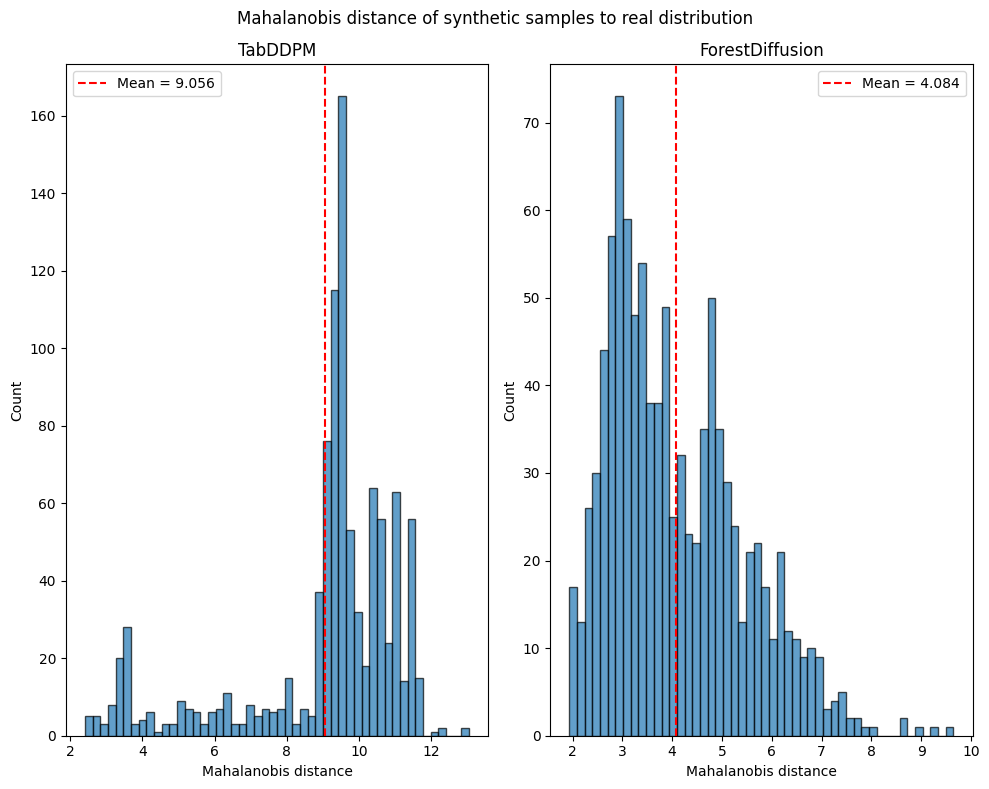

In [33]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(model_order), figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_cancer_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [34]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Compute numeric features (exclude target)
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = data[num_cols].to_numpy(dtype=float)

# Compute real covariance inverse (if not already done)
if 'inv_cov_real' not in globals():
    cov_real = np.cov(real_matrix, rowvar=False)
    inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Updated for your models
for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        # REMOVED size check - use min(real, synth) samples
        n_matches = min(real_matrix.shape[0], synth_numeric.shape[0])
        print(f"✓ Processing {name} ({n_matches} matches from {synth_numeric.shape[0]} synth samples)")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary table (only for successful models)
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match",
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")


✓ Processing TabDDPM (1000 matches from 1000 synth samples)
✓ Processing ForestDiffusion (1000 matches from 1000 synth samples)
Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
ForestDiffusion,2.694164,2.573548,1.480913,9.015336,1000.0
TabDDPM,8.314838,9.135763,2.695333,12.471148,1000.0


In [35]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

# Compute numeric features (exclude target)
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = data[num_cols].to_numpy(dtype=float)

# Compute real covariance inverse (if not already done)
if 'inv_cov_real' not in globals():
    cov_real = np.cov(real_matrix, rowvar=False)
    inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Your GAN models
for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        # REMOVED size check - Hungarian handles rectangular matrices automatically
        n_real, n_synth = real_matrix.shape[0], synth_numeric.shape[0]
        n_matches = min(n_real, n_synth)
        print(f"✓ Processing {name}: {n_real} real vs {n_synth} synth → {n_matches} matches")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_real": n_real,
            "n_synth": n_synth,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary table (only for successful models)
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match",
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")


✓ Processing TabDDPM: 1000 real vs 1000 synth → 1000 matches
✓ Processing ForestDiffusion: 1000 real vs 1000 synth → 1000 matches
Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
ForestDiffusion,2.694164,2.573548,1.480913,9.015336,1000.0
TabDDPM,8.314838,9.135763,2.695333,12.471148,1000.0


In [36]:
import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

# Smart synthetic source detection (same as previous cells)
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found.")

# Use same numeric columns as previous Mahalanobis cell
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = data[num_cols].to_numpy(dtype=float)

greedy_results = {}
comparison_rows = []

# Your GAN models
for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source and name in hungarian_results:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        print(f"✓ Processing {name}: {real_matrix.shape[0]} real vs {synth_numeric.shape[0]} synth")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        total_g, mean_g, _ = greedy_one_to_one_matching(D)

        greedy_results[name] = {
            "total_distance": total_g,
            "mean_distance": mean_g
        }

        # Compare with Hungarian results
        h_total = hungarian_results[name]["total_distance"]
        h_mean = hungarian_results[name]["mean_distance_per_match"]

        comparison_rows.append({
            "Model": name,
            "Greedy total": total_g,
            "Hungarian total": h_total,
            "Greedy mean": mean_g,
            "Hungarian mean": h_mean,
            "Total diff (Greedy - Hungarian)": total_g - h_total,
            "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
        })
        print(f"  Greedy mean: {mean_g:.4f} vs Hungarian: {h_mean:.4f} (diff: {mean_g-h_mean:.4f})")
    else:
        print(f"✗ Skipping {name} (missing data or Hungarian results)")

# Greedy summary
if greedy_results:
    greedy_summary = pd.DataFrame({
        name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
        for name in greedy_results
    }, index=["total_distance", "mean_distance"]).T
    greedy_summary.index.name = "Model"

    print("Greedy one-to-one matching (Mahalanobis distance):")
    display(greedy_summary)

    print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
    comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
    display(comparison_df)
else:
    print("No valid models for greedy matching.")

✓ Processing TabDDPM: 1000 real vs 1000 synth
  Greedy mean: 8.5135 vs Hungarian: 8.3148 (diff: 0.1986)
✓ Processing ForestDiffusion: 1000 real vs 1000 synth
  Greedy mean: 2.7934 vs Hungarian: 2.6942 (diff: 0.0993)
Greedy one-to-one matching (Mahalanobis distance):


,total_distance,mean_distance
Model,,
TabDDPM,8513.464350,8.513464
ForestDiffusion,2793.422877,2.793423



Comparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy - Hungarian),Mean diff (Greedy - Hungarian)
Model,,,,,,
TabDDPM,8513.464350,8314.838497,8.513464,8.314838,198.625852,0.198626
ForestDiffusion,2793.422877,2694.164235,2.793423,2.694164,99.258641,0.099259


In [37]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# Use your data and dynamic target detection
real_df = data.copy()

feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]

X_real = real_df[feature_cols].to_numpy(dtype=float)

# Covariance with regularization (pinv is better than inv for stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models
model_order = ["TabDDPM", "ForestDiffusion"]
hungarian_results = {}

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name][real_df.columns].copy()
        X_synth = synth_df[feature_cols].to_numpy(dtype=float)

        print(f"✓ Processing {model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")

        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian handles rectangular matrices automatically
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]

        hungarian_results[model_name] = {
            "row_ind": row_ind,
            "col_ind": col_ind,
            "dists": dists
        }

        # Top matches
        order = np.argsort(dists)
        top_k = min(20, len(order))
        print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
        for rank, k in enumerate(order[:top_k], 1):
            print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")
    else:
        print(f"✗ {model_name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary stats
if hungarian_results:
    summary_stats = pd.DataFrame({
        model_name: {
            "mean_dist": np.mean(hungarian_results[model_name]["dists"]),
            "median_dist": np.median(hungarian_results[model_name]["dists"]),
            "min_dist": np.min(hungarian_results[model_name]["dists"])
        }
        for model_name in hungarian_results
    }).T.sort_values("mean_dist")
    print("\nSummary Mahalanobis distances (lower is better):")
    display(summary_stats)


✓ Processing TabDDPM: 1000 real vs 1000 synth

TabDDPM - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R688 -> S357   distance = 0.0631
02. R543 -> S207   distance = 0.4170
03. R427 -> S193   distance = 0.4402
04. R665 -> S755   distance = 0.5216
05. R630 -> S464   distance = 0.6054
06. R851 -> S857   distance = 0.7107
07. R269 -> S672   distance = 0.7180
08. R542 -> S677   distance = 0.8381
09. R446 -> S516   distance = 0.8733
10. R189 -> S175   distance = 0.8794
11. R341 -> S384   distance = 0.9614
12. R69 -> S707   distance = 0.9747
13. R934 -> S462   distance = 1.0576
14. R572 -> S43   distance = 1.0761
15. R234 -> S637   distance = 1.1665
16. R637 -> S450   distance = 1.2216
17. R764 -> S717   distance = 1.2886
18. R604 -> S339   distance = 1.3111
19. R803 -> S72   distance = 1.3195
20. R726 -> S951   distance = 1.3767
✓ Processing ForestDiffusion: 1000 real vs 1000 synth

ForestDiffusion - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R220 -> S849 

,mean_dist,median_dist,min_dist
ForestDiffusion,2.694164,2.573548,0.08615
TabDDPM,8.314838,9.135763,0.06306


In [38]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import pandas as pd

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found.")

# Use your data with dynamic target detection
real_df = data.copy()

feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]

X_real = real_df[feature_cols].to_numpy(dtype=float)

# Covariance with regularization
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models
model_order = ["TabDDPM", "ForestDiffusion"]

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name][real_df.columns].copy()
        X_synth = synth_df[feature_cols].to_numpy(dtype=float)

        print(f"\n{'='*60}")
        print(f"{model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")
        print(f"{'='*60}")

        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Simplified Hungarian (handles rectangular matrices automatically)
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]

        r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

        print(f"{model_name} - Hungarian mappings for R1 to R20:")
        for r in range(20):
            if r in r_to_match:
                s, dist = r_to_match[r]
                print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
            else:
                print(f"R{r+1} -> No match found")

        # Summary stats for this model
        print(f"  Summary: mean={np.mean(dists):.4f}, median={np.median(dists):.4f}, min={np.min(dists):.4f}")
    else:
        print(f"✗ {model_name} not in synthetic source. Available: {list(synth_source.keys())}")



TabDDPM: 1000 real vs 1000 synth
TabDDPM - Hungarian mappings for R1 to R20:
R1 -> S361   distance = 1.6468
R2 -> S916   distance = 8.0484
R3 -> S174   distance = 6.4405
R4 -> S900   distance = 10.8769
R5 -> S602   distance = 9.4899
R6 -> S829   distance = 9.3719
R7 -> S656   distance = 8.7549
R8 -> S16   distance = 10.6094
R9 -> S905   distance = 8.7676
R10 -> S467   distance = 10.2816
R11 -> S162   distance = 7.5891
R12 -> S446   distance = 10.1958
R13 -> S525   distance = 11.1049
R14 -> S579   distance = 10.4643
R15 -> S931   distance = 10.7801
R16 -> S402   distance = 2.3175
R17 -> S743   distance = 8.4984
R18 -> S389   distance = 9.7059
R19 -> S340   distance = 7.7966
R20 -> S67   distance = 10.8344
  Summary: mean=8.3148, median=9.1358, min=0.0631

ForestDiffusion: 1000 real vs 1000 synth
ForestDiffusion - Hungarian mappings for R1 to R20:
R1 -> S931   distance = 2.2427
R2 -> S860   distance = 2.4820
R3 -> S456   distance = 3.8189
R4 -> S836   distance = 3.2292
R5 -> S396   dist


Processing TabDDPM: 1000 real vs 1000 synth


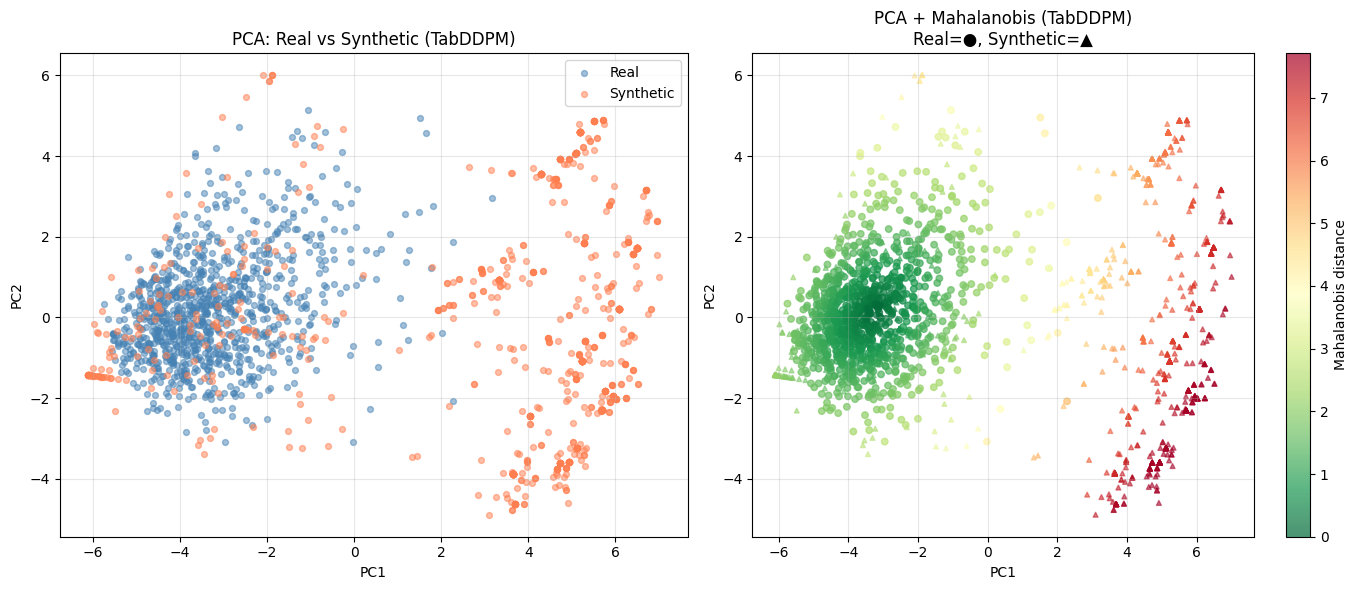

  Real mean MD: 1.2230, Synth mean MD: 5.6759, Delta: +4.4529

Processing ForestDiffusion: 1000 real vs 1000 synth


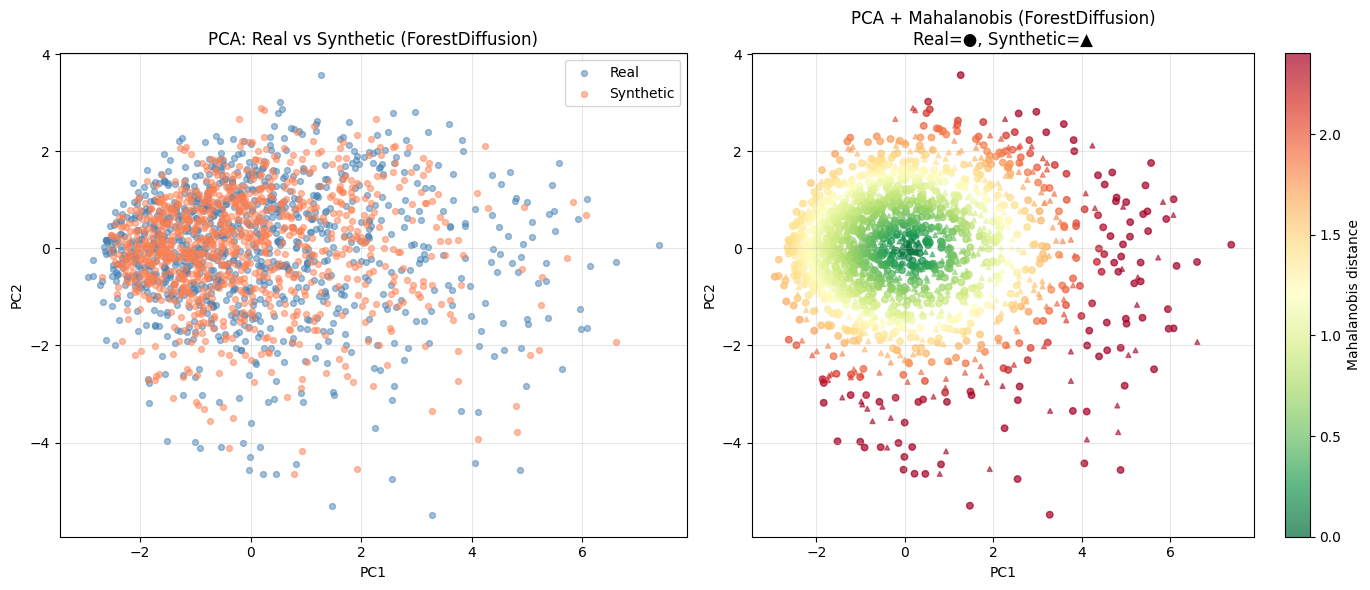

  Real mean MD: 1.2343, Synth mean MD: 1.0777, Delta: -0.1566

Summary: PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
1,ForestDiffusion,1.234332,1.077685,-0.156646
0,TabDDPM,1.222997,5.675944,4.452947


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found.")

# Your data and GAN models
model_order = ["TabDDPM", "ForestDiffusion"]
real_df = data.copy()

feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

X_r = real_df[feature_cols].to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic source, skipping.")
        continue

    synth_df = synth_source[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    print(f"\n{'='*60}")
    print(f"Processing {model_name}: {X_r.shape[0]} real vs {X_s.shape[0]} synth")
    print(f"{'='*60}")

    # PCA on combined data
    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    # Mahalanobis in PCA space (real distribution reference)
    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    # Plot 1: PCA scatter
    fig, axes = plt.subplots(1, len(model_order), figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Mahalanobis distance color-coded
    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Stats
    print(f"  Real mean MD: {d_r.mean():.4f}, Synth mean MD: {d_s.mean():.4f}, Delta: {d_s.mean()-d_r.mean():+.4f}")

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

# Summary table
if rows:
    summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
    print("\nSummary: PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):")
    display(summary_df)
else:
    print("No valid models found.")


In [40]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_WGAN_TabDDPM.xlsx"
):
    # Updated for your GAN models
    model_order = ["TabDDPM", "ForestDiffusion"]

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                print(f"Skipping {model_name}: missing data or results")
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            # Flexible distance key detection
            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                print(f"No distance array found for {model_name}, skipping")
                continue

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = model_name[:31]  # Excel sheet name limit
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"✓ Exported {len(matched_df)} matches for {model_name}")

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)
            print("\nSummary table:")
            display(summary_df)

    print(f"\n✅ Excel file created: {filename}")

# ---- Run ----
# Smart source detection + your dataset
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found.")

real_df = data.copy()

num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

print(f"Dataset: {len(real_df)} samples, {len(num_cols)} numeric features")
print(f"Target column: {target_col}")

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synth_source,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_WGAN_TabDDPM.xlsx"
)


Dataset: 1000 samples, 21 numeric features
Target column: Diabetes_binary
✓ Exported 1000 matches for TabDDPM
✓ Exported 1000 matches for ForestDiffusion

Summary table:


,Model,Num_Matches,Mean_Distance,Median_Distance,Std_Distance,Min_Distance,Max_Distance
1,ForestDiffusion,1000,2.694164,2.573548,1.480913,0.08615,9.015336
0,TabDDPM,1000,8.314838,9.135763,2.695333,0.06306,12.471148



✅ Excel file created: Hungarian_Mahalanobis_WGAN_TabDDPM.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [41]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    # For multi-class, y needs to be converted to integer indices if not already
    if y.dtype == 'object': # Handle case where y might be strings like 'A', 'B'
        unique_labels = np.unique(y)
        label_to_int = {label: i for i, label in enumerate(unique_labels)}
        y_int = np.array([label_to_int[label] for label in y])
    else:
        y_int = y.astype(int)

    # Ensure y_int values are valid indices for proba.shape[1]
    y_idx = y_int.clip(0, proba.shape[1] - 1)

    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    # Scores are lower for 'member' (trained on) samples
    scores = -np.concatenate([loss_train, loss_test])
    # Labels: 1 for member (trained on), 0 for non-member (not trained on)
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

# Setup with label encoding
target_col = "Diabetes_binary" # Corrected target column
feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]

real_df = data.copy()
model_order = ["TabDDPM", "ForestDiffusion"]

# Encode target labels once (only if target was categorical, but it is numeric)
# Diabetes_binary is numeric 0/1
y_real_target = real_df[target_col].values

results = []

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic source")
        continue

    print(f"\n{'='*50}")
    print(f"MIA for {model_name}")
    print(f"{'='*50}")

    synth_df = synth_source[model_name][real_df.columns].copy()

    # Use Diabetes_binary directly for synthetic data
    y_synth_target = synth_df[target_col].values

    X_train = real_df[feature_cols].to_numpy(dtype=float)
    y_train = y_real_target

    X_test = synth_df[feature_cols].to_numpy(dtype=float)
    y_test = y_synth_target

    model = LogisticRegression(max_iter=1000, random_state=42)
    metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)

    metrics["Model"] = model_name
    results.append(metrics)

    print(f"  AUC: {metrics['AUC']:.4f}")
    print(f"  Advantage: {metrics['Advantage']:.4f}")
    print(f"  TPR@FPR=0.01: {metrics['TPR_at_FPR_001']:.4f}")

# Summary
if results:
    summary_df = pd.DataFrame(results).set_index("Model")
    print("\n MIA Results (LOWER AUC = BETTER privacy):")
    display(summary_df.sort_values("AUC"))



MIA for TabDDPM
  AUC: 0.8059
  Advantage: 0.5860
  TPR@FPR=0.01: 0.0050

MIA for ForestDiffusion
  AUC: 0.4791
  Advantage: 0.0330
  TPR@FPR=0.01: 0.0190

 MIA Results (LOWER AUC = BETTER privacy):


,AUC,Advantage,TPR_at_FPR_001
Model,,,
ForestDiffusion,0.479052,0.033,0.019
TabDDPM,0.805878,0.586,0.005


In [42]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns
                if c not in ["y"]]
X_train = data[feature_cols].to_numpy(dtype=float)

model_order = ["TabDDPM", "ForestDiffusion"]
rows = []

print("Mahalanobis MIA - Real vs Synthetic (TabDDPM & ForestDiffusion)")
print("="*70)

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic source, skipping")
        continue

    print(f"\n✓ Processing {model_name}...")
    X_test = synth_source[model_name][feature_cols].to_numpy(dtype=float)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

# Results table
if rows:
    comparison_df = pd.DataFrame(rows)[
        ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
    ].sort_values("AUC", ascending=False).reset_index(drop=True)

    print("\nMIA (Mahalanobis) Results:")
    print("• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)")
    print("• Train/Test MD: How far synthetic data is from real distribution")
    display(comparison_df)

    # Privacy ranking
    print("\nPrivacy Ranking (LOWER AUC = BETTER privacy):")
    ranked = comparison_df.sort_values("AUC").reset_index(drop=True)
    for idx, row in ranked.iterrows():
        rank_emoji = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
        print(f"{rank_emoji} {row['Model']}: AUC={row['AUC']:.3f}")
else:
    print("No valid models found.")


Mahalanobis MIA - Real vs Synthetic (TabDDPM & ForestDiffusion)

✓ Processing TabDDPM...

✓ Processing ForestDiffusion...

MIA (Mahalanobis) Results:
• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)
• Train/Test MD: How far synthetic data is from real distribution


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,TabDDPM,0.931165,0.818,0.154,4.46947,9.264573
1,ForestDiffusion,0.438942,0.001,0.000,4.46947,4.181211



Privacy Ranking (LOWER AUC = BETTER privacy):
🥇 ForestDiffusion: AUC=0.439
🥈 TabDDPM: AUC=0.931
